# Hybrid Comparison Analysis




In [ ]:
# Optional: mount Google Drive when running in Colab
try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False

print(f"IN_COLAB = {IN_COLAB}")

Mounted at /content/drive
IN_COLAB = True


In [ ]:
# Imports

import os
import json
import math
import glob
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from IPython.display import display, Markdown
from sklearn.metrics import ConfusionMatrixDisplay
from scipy import stats
from scipy.optimize import curve_fit

warnings.filterwarnings("ignore", category=RuntimeWarning)

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## 1. Configure paths

In [ ]:
# Path configuration

from pathlib import Path

MYDRIVE = Path("/content/drive/MyDrive")

PREFERRED_ROOTS = [
    MYDRIVE / "MSC_Research" / "Hybrids",
    MYDRIVE / "MSC Research" / "Hybrids",
]

def pick_hybrid_root():
    for root in PREFERRED_ROOTS:
        if (root / "Results" / "Run_JSON").exists() or (root / "Models").exists():
            return root

    for root in PREFERRED_ROOTS:
        if root.exists():
            return root

    # Fallback discovery for unexpected layouts
    for json_fp in MYDRIVE.glob("**/*_results.json"):
        p = json_fp.parent
        if p.name.lower() == "run_json" and p.parent.name.lower() == "results":
            return p.parent.parent

    for models_dir in MYDRIVE.glob("**/Models"):
        parent = models_dir.parent
        if parent.name.lower() == "hybrids":
            return parent

    return PREFERRED_ROOTS[0]

HYBRIDS_ROOT = pick_hybrid_root()
CONFIGS_DIR = HYBRIDS_ROOT / "Configs"
CONFIG_PATH = CONFIGS_DIR / "Hybrid_Config.csv"
RESULTS_ROOT = HYBRIDS_ROOT / "Results"
RUN_ARTIFACTS_DIR = RESULTS_ROOT / "Run_JSON"
MODELS_DIR = HYBRIDS_ROOT / "Models"
ATTENTION_DIR = HYBRIDS_ROOT / "Attention_Rollout"
GRADCAM_DIR = HYBRIDS_ROOT / "Grad Cam"

TABLE_DIR = HYBRIDS_ROOT / "Analysis_Tables"
FIG_DIR = HYBRIDS_ROOT / "Analysis_Figures"

for d in [TABLE_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("HYBRIDS_ROOT      :", HYBRIDS_ROOT)
print("CONFIG_PATH       :", CONFIG_PATH)
print("RUN_ARTIFACTS_DIR :", RUN_ARTIFACTS_DIR)
print("MODELS_DIR        :", MODELS_DIR)
print("ATTENTION_DIR     :", ATTENTION_DIR)
print("GRADCAM_DIR       :", GRADCAM_DIR)
print("TABLE_DIR         :", TABLE_DIR)
print("FIG_DIR           :", FIG_DIR)


HYBRIDS_ROOT      : /content/drive/MyDrive/MSC_Research/Hybrids
CONFIG_PATH       : /content/drive/MyDrive/MSC_Research/Hybrids/Configs/Hybrid_Config.csv
RUN_ARTIFACTS_DIR : /content/drive/MyDrive/MSC_Research/Hybrids/Results/Run_JSON
MODELS_DIR        : /content/drive/MyDrive/MSC_Research/Hybrids/Models
ATTENTION_DIR     : /content/drive/MyDrive/MSC_Research/Hybrids/Attention_Rollout
GRADCAM_DIR       : /content/drive/MyDrive/MSC_Research/Hybrids/Grad Cam
TABLE_DIR         : /content/drive/MyDrive/MSC_Research/Hybrids/Analysis_Tables
FIG_DIR           : /content/drive/MyDrive/MSC_Research/Hybrids/Analysis_Figures


In [ ]:
# Quick path checks with Hybrid-first discovery

def choose_best_paths():
    json_direct = sorted(RUN_ARTIFACTS_DIR.glob("*_results.json")) if RUN_ARTIFACTS_DIR.exists() else []
    csv_direct = sorted([p for p in MODELS_DIR.glob("*.csv") if p.name.lower() != "hybrid_config.csv"]) if MODELS_DIR.exists() else []
    attn_direct = sorted([p for p in ATTENTION_DIR.glob("*") if p.is_dir()]) if ATTENTION_DIR.exists() else []
    gradcam_direct = sorted([p for p in GRADCAM_DIR.glob("*") if p.is_dir()]) if GRADCAM_DIR.exists() else []

    if json_direct or csv_direct or attn_direct or gradcam_direct:
        return {
            "json_files": json_direct,
            "csv_files": csv_direct,
            "attention_runs": attn_direct,
            "gradcam_runs": gradcam_direct,
            "run_artifacts_dir": RUN_ARTIFACTS_DIR,
            "models_dir": MODELS_DIR,
            "attention_dir": ATTENTION_DIR,
            "gradcam_dir": GRADCAM_DIR,
            "mode": "hybrid_primary_paths",
        }

    json_fallback = sorted([
        p for p in MYDRIVE.glob("**/*_results.json")
        if "hybrids" in str(p).lower()
    ])
    csv_fallback = sorted([
        p for p in MYDRIVE.glob("**/*.csv")
        if "hybrids" in str(p).lower() and "config" not in p.name.lower()
    ])
    attn_fallback = sorted([
        p for p in MYDRIVE.glob("**/Attention_Rollout/*")
        if p.is_dir() and "hybrids" in str(p).lower()
    ])
    gradcam_fallback = sorted([
        p for p in MYDRIVE.glob("**/Grad Cam/*")
        if p.is_dir() and "hybrids" in str(p).lower()
    ])

    return {
        "json_files": json_fallback,
        "csv_files": csv_fallback,
        "attention_runs": attn_fallback,
        "gradcam_runs": gradcam_fallback,
        "run_artifacts_dir": RUN_ARTIFACTS_DIR,
        "models_dir": MODELS_DIR,
        "attention_dir": ATTENTION_DIR,
        "gradcam_dir": GRADCAM_DIR,
        "mode": "hybrid_fallback_search",
    }

path_state = choose_best_paths()
json_files = path_state["json_files"]
csv_files = path_state["csv_files"]
attention_runs = path_state["attention_runs"]
gradcam_runs = path_state["gradcam_runs"]

print("Path resolution mode :", path_state["mode"])
print("Resolved RUN_ARTIFACTS_DIR:", path_state["run_artifacts_dir"])
print("Resolved MODELS_DIR       :", path_state["models_dir"])
print("Resolved ATTENTION_DIR    :", path_state["attention_dir"])
print("Resolved GRADCAM_DIR      :", path_state["gradcam_dir"])
print("JSON bundles found    :", len(json_files))
print("Model CSVs found      :", len(csv_files))
print("Attention runs found  :", len(attention_runs))
print("Grad-CAM runs found   :", len(gradcam_runs))

if len(json_files) == 0:
    print("WARNING: No JSON bundles found. Check HYBRIDS_ROOT / Results / Run_JSON.")
if len(csv_files) == 0:
    print("WARNING: No model CSVs found. Check HYBRIDS_ROOT / Models.")


Path resolution mode : hybrid_primary_paths
Resolved RUN_ARTIFACTS_DIR: /content/drive/MyDrive/MSC_Research/Hybrids/Results/Run_JSON
Resolved MODELS_DIR       : /content/drive/MyDrive/MSC_Research/Hybrids/Models
Resolved ATTENTION_DIR    : /content/drive/MyDrive/MSC_Research/Hybrids/Attention_Rollout
Resolved GRADCAM_DIR      : /content/drive/MyDrive/MSC_Research/Hybrids/Grad Cam
JSON bundles found    : 18
Model CSVs found      : 126
Attention runs found  : 18
Grad-CAM runs found   : 18


## 2. Load saved run bundles

In [ ]:
def safe_read_json(path):
    with open(path, "r") as f:
        return json.load(f)

def to_dataframe(records, extra=None):
    if records is None:
        return pd.DataFrame()
    if isinstance(records, dict):
        records = [records]
    df = pd.DataFrame(records)
    if extra:
        for k, v in extra.items():
            df[k] = v
    return df

bundles = []
for fp in json_files:
    try:
        bundle = safe_read_json(fp)
        bundle["_source_json"] = str(fp)
        bundles.append(bundle)
    except Exception as e:
        print(f"Failed to read {fp.name}: {e}")

print(f"Loaded {len(bundles)} bundles.")

Loaded 18 bundles.


In [ ]:
# Flatten key tables from each bundle

final_frames = []
history_frames = []
per_class_frames = []
pred_frames = []
split_frames = []
attention_meta_frames = []
confusion_store = {}

for b in bundles:
    run_id = b.get("run_id")
    dataset = b.get("dataset")
    model = b.get("model")
    metadata = b.get("metadata", {})

    final_frames.append(to_dataframe(b.get("final_summary"), {
        "run_id": run_id, "dataset": dataset, "model": model
    }))

    history_frames.append(to_dataframe(b.get("history"), {
        "run_id": run_id, "dataset": dataset, "model": model
    }))

    per_class_frames.append(to_dataframe((b.get("metrics") or {}).get("per_class_test"), {
        "run_id": run_id, "dataset": dataset, "model": model
    }))

    preds = b.get("predictions", {})
    for split_name, rows in preds.items():
        pred_frames.append(to_dataframe(rows, {
            "run_id": run_id, "dataset": dataset, "model": model, "pred_split": split_name
        }))

    splits = b.get("splits", {})
    for split_name, rows in splits.items():
        split_frames.append(to_dataframe(rows, {
            "run_id": run_id, "dataset": dataset, "model": model, "saved_split_name": split_name
        }))

    manifest = b.get("manifest", {})
    if manifest:
        attention_meta_frames.append(pd.DataFrame([{
            "run_id": run_id,
            "dataset": dataset,
            "model": model,
            "explanation_method": manifest.get("explanation_method"),
            "attention_dir": manifest.get("attention_dir"),
        }]))

    cm = (b.get("metrics") or {}).get("confusion_matrix_test")
    if cm is not None:
        confusion_store[run_id] = np.array(cm)

final_df = pd.concat(final_frames, ignore_index=True) if final_frames else pd.DataFrame()
history_df = pd.concat(history_frames, ignore_index=True) if history_frames else pd.DataFrame()
per_class_df = pd.concat(per_class_frames, ignore_index=True) if per_class_frames else pd.DataFrame()
pred_df = pd.concat(pred_frames, ignore_index=True) if pred_frames else pd.DataFrame()
split_df = pd.concat(split_frames, ignore_index=True) if split_frames else pd.DataFrame()
attention_df = pd.concat(attention_meta_frames, ignore_index=True) if attention_meta_frames else pd.DataFrame()

print("final_df   ", final_df.shape)
print("history_df ", history_df.shape)
print("per_class_df", per_class_df.shape)
print("pred_df    ", pred_df.shape)
print("split_df   ", split_df.shape)
print("attention_df", attention_df.shape)


final_df    (18, 36)
history_df  (373, 26)
per_class_df (117, 8)
pred_df     (84546, 21)
split_df    (194262, 26)
attention_df (18, 5)


In [ ]:
# Standardise types and inspect columns

def numeric_if_present(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

final_df = numeric_if_present(final_df, [
    "seed","data_fraction_requested","data_fraction_used","best_epoch","epochs_trained","stopped_early",
    "final_val_loss","final_val_acc","final_val_balanced_acc","final_val_f1_macro","final_val_f1_weighted","final_val_auroc_ovr",
    "test_loss","test_acc","test_balanced_acc","test_f1_macro","test_f1_weighted","test_auroc_ovr",
    "total_params","trainable_params","run_seconds","dropout_p","batch_size","img_size","best_val_loss"
])

history_df = numeric_if_present(history_df, [
    "epoch","seed","data_fraction_requested","data_fraction_used","train_loss","train_acc","train_f1_macro","train_n_seen","train_seconds",
    "val_loss","val_acc","val_balanced_acc","val_f1_macro","val_f1_weighted","val_auroc_ovr","val_n_seen",
    "lr","best_val_loss_so_far","best_epoch_so_far","patience_counter"
])

per_class_df = numeric_if_present(per_class_df, ["precision","recall","f1-score","support","seed","data_fraction_requested","data_fraction_used"])
pred_df = numeric_if_present(pred_df, ["true_label","pred_label","correct","confidence","seed","data_fraction_requested","data_fraction_used"])
attention_df = numeric_if_present(attention_df, ["index","true_label","pred_label","correct","confidence","seed","data_fraction_requested","data_fraction_used"])

display(final_df.head())
print("\nColumns in final_df:")
print(sorted(final_df.columns.tolist()))

# Backfill key run-level columns into child tables when they are missing
run_level_cols = ["run_id", "dataset", "model", "seed", "data_fraction_requested", "data_fraction_used"]
run_level_lookup = pd.DataFrame()
if len(final_df) and "run_id" in final_df.columns:
    available = [c for c in run_level_cols if c in final_df.columns]
    run_level_lookup = final_df[available].drop_duplicates(subset=["run_id"]).copy()


def attach_run_level_columns(df):
    if len(df) == 0 or len(run_level_lookup) == 0 or "run_id" not in df.columns:
        return df
    missing = [c for c in run_level_lookup.columns if c != "run_id" and c not in df.columns]
    if not missing:
        return df
    return df.merge(run_level_lookup[["run_id", *missing]], on="run_id", how="left")

per_class_df = attach_run_level_columns(per_class_df)
pred_df = attach_run_level_columns(pred_df)
attention_df = attach_run_level_columns(attention_df)
split_df = attach_run_level_columns(split_df)

per_class_df = numeric_if_present(per_class_df, ["precision","recall","f1-score","f1_score","support","seed","data_fraction_requested","data_fraction_used","class_id"])
pred_df = numeric_if_present(pred_df, ["true_label","pred_label","correct","confidence","seed","data_fraction_requested","data_fraction_used"])
attention_df = numeric_if_present(attention_df, ["index","true_label","pred_label","correct","confidence","seed","data_fraction_requested","data_fraction_used"])


,run_id,dataset,model,seed,data_fraction_requested,data_fraction_used,num_classes,best_epoch,epochs_trained,stopped_early,...,run_time_hms,device,batch_size,img_size,dropout_p,drop_path_rate,label_smoothing,warmup_epochs,base_lr,weight_decay
0,ISIC2019_ViT x CNN_100_42,ISIC2019,ViT x CNN,42,1.00,1.00,8,5,10,1,...,01:03:31,cuda,16,224,0.1,0.1,0.05,3,0.0001,0.0001
1,ISIC2019_ViT x CNN_100_43,ISIC2019,ViT x CNN,43,1.00,1.00,8,7,12,1,...,01:15:49,cuda,16,224,0.1,0.1,0.05,3,0.0001,0.0001
2,ISIC2019_ViT x CNN_100_44,ISIC2019,ViT x CNN,44,1.00,1.00,8,22,25,0,...,02:35:36,cuda,16,224,0.1,0.1,0.05,3,0.0001,0.0001
3,ISIC2019_ViT x CNN_25_42,ISIC2019,ViT x CNN,42,0.25,0.25,8,21,25,0,...,01:40:24,cuda,16,224,0.1,0.1,0.05,3,0.0001,0.0001
4,ISIC2019_ViT x CNN_25_43,ISIC2019,ViT x CNN,43,0.25,0.25,8,21,25,0,...,01:40:37,cuda,16,224,0.1,0.1,0.05,3,0.0001,0.0001



Columns in final_df:
['base_lr', 'batch_size', 'best_epoch', 'best_val_loss', 'data_fraction_requested', 'data_fraction_used', 'dataset', 'device', 'drop_path_rate', 'dropout_p', 'epochs_trained', 'final_val_acc', 'final_val_auroc_ovr', 'final_val_balanced_acc', 'final_val_f1_macro', 'final_val_f1_weighted', 'final_val_loss', 'img_size', 'label_smoothing', 'model', 'num_classes', 'run_id', 'run_seconds', 'run_time_hms', 'seed', 'stopped_early', 'test_acc', 'test_auroc_ovr', 'test_balanced_acc', 'test_f1_macro', 'test_f1_weighted', 'test_loss', 'total_params', 'trainable_params', 'warmup_epochs', 'weight_decay']


## 3. Coverage checks

In [ ]:
def show_unique(df, col):
    return sorted(df[col].dropna().astype(str).unique().tolist()) if col in df.columns else []

print("Datasets :", show_unique(final_df, "dataset"))
print("Models   :", show_unique(final_df, "model"))
print("Fractions:", sorted(final_df["data_fraction_used"].dropna().unique().tolist()) if "data_fraction_used" in final_df.columns else [])
print("Seeds    :", sorted(final_df["seed"].dropna().unique().tolist()) if "seed" in final_df.columns else [])

Datasets : ['ISIC2019', 'Messidor2']
Models   : ['ViT x CNN']
Fractions: [0.25, 0.5, 1.0]
Seeds    : [42, 43, 44]


In [ ]:
coverage = (
    final_df.groupby(["dataset","model","data_fraction_used"])
    .agg(
        n_runs=("run_id","nunique"),
        seeds=("seed", lambda s: sorted(pd.Series(s).dropna().astype(int).tolist()))
    )
    .reset_index()
    .sort_values(["dataset","model","data_fraction_used"])
)
display(coverage)
coverage.to_csv(TABLE_DIR / "coverage_table.csv", index=False)

,dataset,model,data_fraction_used,n_runs,seeds
0,ISIC2019,ViT x CNN,0.25,3,"[42, 43, 44]"
1,ISIC2019,ViT x CNN,0.50,3,"[42, 43, 44]"
2,ISIC2019,ViT x CNN,1.00,3,"[42, 43, 44]"
3,Messidor2,ViT x CNN,0.25,3,"[42, 43, 44]"
4,Messidor2,ViT x CNN,0.50,3,"[42, 43, 44]"
5,Messidor2,ViT x CNN,1.00,3,"[42, 43, 44]"


## 4. Helper functions for summaries and plots

In [ ]:
PRIMARY_METRIC = "test_f1_macro"
SECONDARY_METRICS = ["test_acc", "test_balanced_acc", "test_auroc_ovr", "test_loss"]

MODEL_ORDER = sorted(show_unique(final_df, "model"))
DATASET_ORDER = sorted(show_unique(final_df, "dataset"))
FRACTION_ORDER = sorted(final_df["data_fraction_used"].dropna().unique().tolist())

def mean_std_summary(df, group_cols, metrics):
    agg = {}
    for m in metrics:
        agg[m] = ["mean", "std", "min", "max", "count"]
    out = df.groupby(group_cols).agg(agg)
    out.columns = ["_".join(col).strip() for col in out.columns]
    return out.reset_index()

def ci95(series):
    x = pd.Series(series).dropna().astype(float)
    if len(x) <= 1:
        return np.nan
    return stats.t.ppf(0.975, df=len(x)-1) * x.std(ddof=1) / np.sqrt(len(x))

def save_current_fig(name):
    png = FIG_DIR / f"{name}.png"
    pdf = FIG_DIR / f"{name}.pdf"
    plt.savefig(png, bbox_inches="tight")
    plt.savefig(pdf, bbox_inches="tight")
    print(f"Saved: {png.name}, {pdf.name}")

def pretty_metric_name(metric):
    mapping = {
        "test_f1_macro": "Test Macro F1",
        "test_acc": "Test Accuracy",
        "test_balanced_acc": "Test Balanced Accuracy",
        "test_auroc_ovr": "Test AUROC (OvR)",
        "test_loss": "Test Loss",
        "final_val_f1_macro": "Validation Macro F1",
        "val_loss": "Validation Loss",
        "train_loss": "Training Loss",
    }
    return mapping.get(metric, metric)

def format_mean_std(mean, std, digits=4):
    if pd.isna(mean):
        return ""
    if pd.isna(std):
        return f"{mean:.{digits}f}"
    return f"{mean:.{digits}f} ± {std:.{digits}f}"

## 5. Main performance tables

In [ ]:
summary_main = mean_std_summary(
    final_df,
    ["dataset", "model", "data_fraction_used"],
    [PRIMARY_METRIC] + SECONDARY_METRICS
).sort_values(["dataset","model","data_fraction_used"])

display(summary_main)
summary_main.to_csv(TABLE_DIR / "main_performance_summary.csv", index=False)

,dataset,model,data_fraction_used,test_f1_macro_mean,test_f1_macro_std,test_f1_macro_min,test_f1_macro_max,test_f1_macro_count,test_acc_mean,test_acc_std,...,test_auroc_ovr_mean,test_auroc_ovr_std,test_auroc_ovr_min,test_auroc_ovr_max,test_auroc_ovr_count,test_loss_mean,test_loss_std,test_loss_min,test_loss_max,test_loss_count
0,ISIC2019,ViT x CNN,0.25,0.365389,0.017049,0.345708,0.375630,3,0.511872,0.018365,...,0.798452,0.004419,0.793828,0.802634,3,1.511907,0.020676,1.488539,1.527827,3
1,ISIC2019,ViT x CNN,0.50,0.391873,0.021474,0.379445,0.416669,3,0.540516,0.017283,...,0.816178,0.002038,0.813875,0.817751,3,1.459260,0.026027,1.429207,1.474446,3
2,ISIC2019,ViT x CNN,1.00,0.365348,0.054262,0.320035,0.425481,3,0.541808,0.019031,...,0.804843,0.022475,0.780581,0.824952,3,1.469057,0.017529,1.449734,1.483938,3
3,Messidor2,ViT x CNN,0.25,0.165067,0.048744,0.124675,0.219210,3,0.440252,0.039277,...,0.596845,0.050182,0.546888,0.647250,3,1.373449,0.040538,1.329867,1.410030,3
4,Messidor2,ViT x CNN,0.50,0.237533,0.085954,0.175873,0.335717,3,0.459119,0.005447,...,0.708049,0.033867,0.669028,0.729795,3,1.319611,0.019591,1.307131,1.342191,3
5,Messidor2,ViT x CNN,1.00,0.178548,0.031540,0.156549,0.214683,3,0.432390,0.029957,...,0.671227,0.005943,0.664392,0.675172,3,1.391873,0.088660,1.290099,1.452355,3


In [ ]:
# Compact dissertation-ready table

compact_rows = []
for _, row in summary_main.iterrows():
    compact_rows.append({
        "dataset": row["dataset"],
        "model": row["model"],
        "data_fraction_used": row["data_fraction_used"],
        "test_macro_f1": format_mean_std(row.get("test_f1_macro_mean"), row.get("test_f1_macro_std")),
        "test_accuracy": format_mean_std(row.get("test_acc_mean"), row.get("test_acc_std")),
        "test_balanced_accuracy": format_mean_std(row.get("test_balanced_acc_mean"), row.get("test_balanced_acc_std")),
        "test_auroc_ovr": format_mean_std(row.get("test_auroc_ovr_mean"), row.get("test_auroc_ovr_std")),
        "test_loss": format_mean_std(row.get("test_loss_mean"), row.get("test_loss_std")),
        "n_runs": int(row.get("test_f1_macro_count", np.nan)) if not pd.isna(row.get("test_f1_macro_count", np.nan)) else np.nan,
    })

compact_main = pd.DataFrame(compact_rows)
display(compact_main)
compact_main.to_csv(TABLE_DIR / "main_performance_compact.csv", index=False)

,dataset,model,data_fraction_used,test_macro_f1,test_accuracy,test_balanced_accuracy,test_auroc_ovr,test_loss,n_runs
0,ISIC2019,ViT x CNN,0.25,0.3654 ± 0.0170,0.5119 ± 0.0184,0.3943 ± 0.0207,0.7985 ± 0.0044,1.5119 ± 0.0207,3
1,ISIC2019,ViT x CNN,0.50,0.3919 ± 0.0215,0.5405 ± 0.0173,0.4263 ± 0.0272,0.8162 ± 0.0020,1.4593 ± 0.0260,3
2,ISIC2019,ViT x CNN,1.00,0.3653 ± 0.0543,0.5418 ± 0.0190,0.3986 ± 0.0672,0.8048 ± 0.0225,1.4691 ± 0.0175,3
3,Messidor2,ViT x CNN,0.25,0.1651 ± 0.0487,0.4403 ± 0.0393,0.2198 ± 0.0237,0.5968 ± 0.0502,1.3734 ± 0.0405,3
4,Messidor2,ViT x CNN,0.50,0.2375 ± 0.0860,0.4591 ± 0.0054,0.2892 ± 0.0713,0.7080 ± 0.0339,1.3196 ± 0.0196,3
5,Messidor2,ViT x CNN,1.00,0.1785 ± 0.0315,0.4324 ± 0.0300,0.3079 ± 0.0624,0.6712 ± 0.0059,1.3919 ± 0.0887,3


## 6. Sample-efficiency comparison

Saved: ISIC2019_sample_efficiency_macro_f1.png, ISIC2019_sample_efficiency_macro_f1.pdf


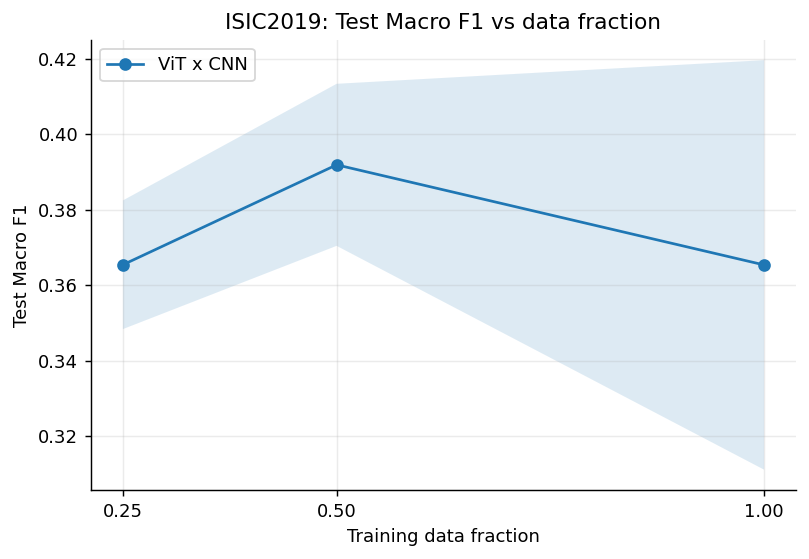

Saved: ISIC2019_sample_efficiency_auroc.png, ISIC2019_sample_efficiency_auroc.pdf


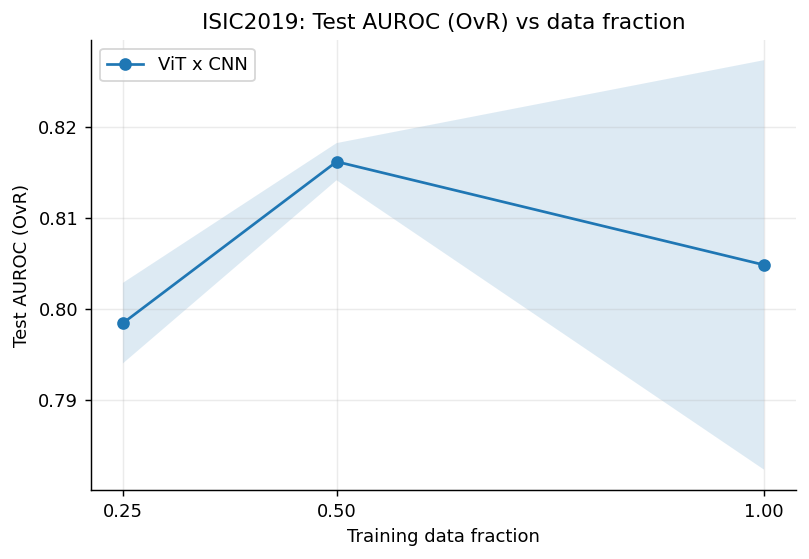

Saved: Messidor2_sample_efficiency_macro_f1.png, Messidor2_sample_efficiency_macro_f1.pdf


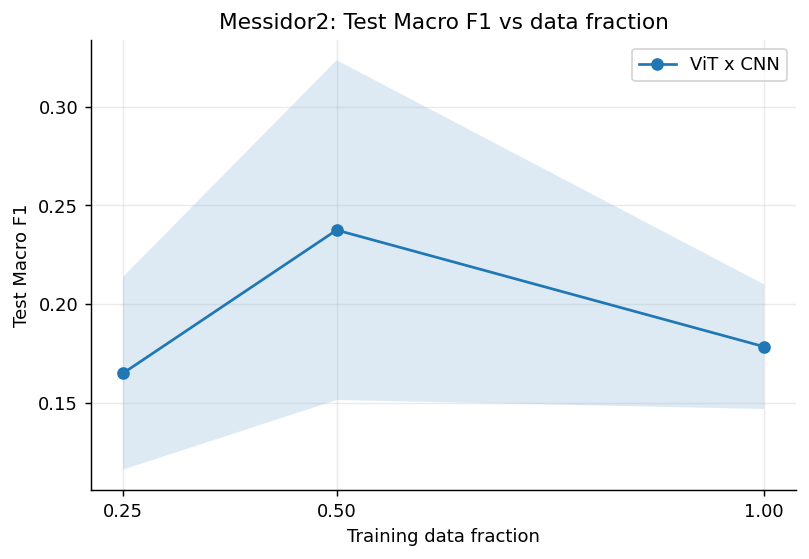

Saved: Messidor2_sample_efficiency_auroc.png, Messidor2_sample_efficiency_auroc.pdf


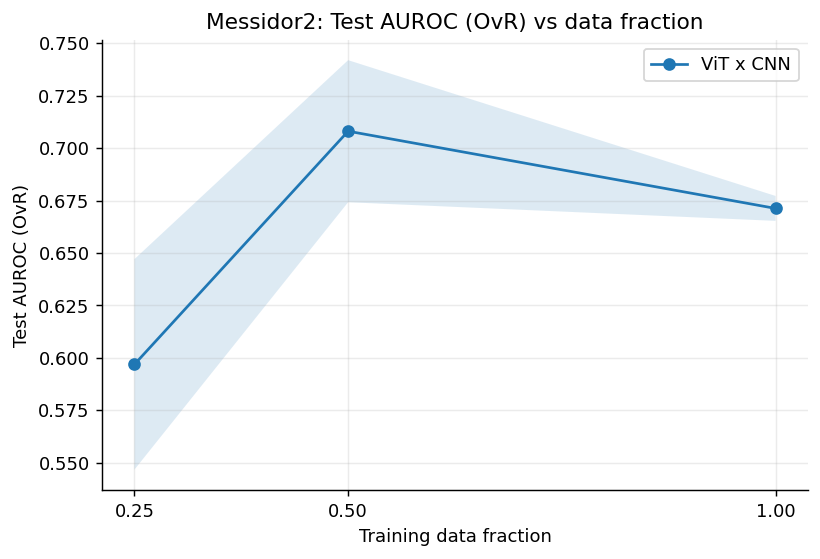

In [ ]:
def plot_metric_vs_fraction(df, metric, dataset_name, title_suffix="", save_name=None):
    d = df[df["dataset"] == dataset_name].copy()
    if len(d) == 0:
        print(f"No rows for dataset={dataset_name}")
        return

    g = (
        d.groupby(["model","data_fraction_used"])[metric]
        .agg(["mean","std","count"])
        .reset_index()
        .sort_values(["model","data_fraction_used"])
    )

    plt.figure(figsize=(7,4.5))
    for model_name in MODEL_ORDER:
        sub = g[g["model"] == model_name].sort_values("data_fraction_used")
        if len(sub) == 0:
            continue
        plt.plot(sub["data_fraction_used"], sub["mean"], marker="o", label=model_name)
        plt.fill_between(
            sub["data_fraction_used"].astype(float).to_numpy(),
            (sub["mean"] - sub["std"].fillna(0)).to_numpy(),
            (sub["mean"] + sub["std"].fillna(0)).to_numpy(),
            alpha=0.15
        )
    plt.xlabel("Training data fraction")
    plt.ylabel(pretty_metric_name(metric))
    plt.title(f"{dataset_name}: {pretty_metric_name(metric)} vs data fraction{title_suffix}")
    plt.xticks(FRACTION_ORDER)
    plt.legend()
    plt.grid(alpha=0.25)
    if save_name:
        save_current_fig(save_name)
    plt.show()

for ds in DATASET_ORDER:
    plot_metric_vs_fraction(final_df, "test_f1_macro", ds, save_name=f"{ds}_sample_efficiency_macro_f1")
    plot_metric_vs_fraction(final_df, "test_auroc_ovr", ds, save_name=f"{ds}_sample_efficiency_auroc")

In [ ]:
# Gains from lower to higher data fractions

gain_rows = []
for (dataset, model), sub in final_df.groupby(["dataset","model"]):
    stats_by_frac = sub.groupby("data_fraction_used")[PRIMARY_METRIC].mean().to_dict()
    ordered = sorted(stats_by_frac.items())
    for i in range(1, len(ordered)):
        prev_frac, prev_val = ordered[i-1]
        frac, val = ordered[i]
        gain_rows.append({
            "dataset": dataset,
            "model": model,
            "from_fraction": prev_frac,
            "to_fraction": frac,
            "mean_metric_prev": prev_val,
            "mean_metric_new": val,
            "absolute_gain": val - prev_val,
            "relative_gain_pct": (100 * (val - prev_val) / prev_val) if prev_val not in [0, np.nan] else np.nan
        })

gain_df = pd.DataFrame(gain_rows)
display(gain_df)
gain_df.to_csv(TABLE_DIR / "sample_efficiency_gains.csv", index=False)

,dataset,model,from_fraction,to_fraction,mean_metric_prev,mean_metric_new,absolute_gain,relative_gain_pct
0,ISIC2019,ViT x CNN,0.25,0.5,0.365389,0.391873,0.026484,7.248256
1,ISIC2019,ViT x CNN,0.50,1.0,0.391873,0.365348,-0.026525,-6.768733
2,Messidor2,ViT x CNN,0.25,0.5,0.165067,0.237533,0.072466,43.900723
3,Messidor2,ViT x CNN,0.50,1.0,0.237533,0.178548,-0.058985,-24.832347


## 6a. Descriptive curve fit

In [ ]:
def log_curve(x, a, b):
    return a + b * np.log(x)

curve_rows = []
for (dataset, model), sub in final_df.groupby(["dataset","model"]):
    grp = sub.groupby("data_fraction_used")[PRIMARY_METRIC].mean().reset_index()
    x = grp["data_fraction_used"].astype(float).to_numpy()
    y = grp[PRIMARY_METRIC].astype(float).to_numpy()
    if len(x) >= 3 and np.all(x > 0):
        try:
            popt, _ = curve_fit(log_curve, x, y, maxfev=10000)
            yhat = log_curve(x, *popt)
            ss_res = np.sum((y - yhat)**2)
            ss_tot = np.sum((y - y.mean())**2)
            r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
            curve_rows.append({
                "dataset": dataset,
                "model": model,
                "curve_a": popt[0],
                "curve_b": popt[1],
                "r2": r2
            })
        except Exception:
            pass

curve_df = pd.DataFrame(curve_rows)
display(curve_df)
curve_df.to_csv(TABLE_DIR / "descriptive_log_curve_fit.csv", index=False)

,dataset,model,curve_a,curve_b,r2
0,ISIC2019,ViT x CNN,0.374183,-0.000029,0.000002
1,Messidor2,ViT x CNN,0.200456,0.009724,0.030586


## 7. Direct model comparison

In [ ]:
pairwise_rows = []

required_cols = {"dataset", "model", "data_fraction_used", PRIMARY_METRIC}
missing_cols = [c for c in required_cols if c not in final_df.columns]
if missing_cols:
    print(f"Cannot build pairwise model comparison. Missing columns: {missing_cols}")
    display(pd.DataFrame())
else:
    dataset_iter = DATASET_ORDER if len(DATASET_ORDER) else sorted(final_df["dataset"].dropna().astype(str).unique().tolist())

    for dataset in dataset_iter:
        sub_d = final_df[final_df["dataset"].astype(str) == str(dataset)].copy()
        if sub_d.empty:
            continue

        models = sorted(sub_d["model"].dropna().astype(str).unique().tolist())
        if len(models) < 2:
            continue

        fractions = sorted(pd.to_numeric(sub_d["data_fraction_used"], errors="coerce").dropna().unique().tolist())
        base = models[0]

        for other in models[1:]:
            for frac in fractions:
                a = pd.to_numeric(
                    sub_d[(sub_d["model"].astype(str) == base) & (pd.to_numeric(sub_d["data_fraction_used"], errors="coerce") == frac)][PRIMARY_METRIC],
                    errors="coerce",
                ).dropna().astype(float)

                b = pd.to_numeric(
                    sub_d[(sub_d["model"].astype(str) == other) & (pd.to_numeric(sub_d["data_fraction_used"], errors="coerce") == frac)][PRIMARY_METRIC],
                    errors="coerce",
                ).dropna().astype(float)

                if len(a) == 0 or len(b) == 0:
                    continue

                diff = float(b.mean() - a.mean())
                pooled_sd = np.sqrt(((a.std(ddof=1) ** 2) + (b.std(ddof=1) ** 2)) / 2) if len(a) > 1 and len(b) > 1 else np.nan
                cohen_d = diff / pooled_sd if pd.notna(pooled_sd) and not np.isclose(pooled_sd, 0) else np.nan

                pairwise_rows.append({
                    "dataset": dataset,
                    "fraction": frac,
                    "model_a": base,
                    "model_b": other,
                    f"{PRIMARY_METRIC}_mean_a": float(a.mean()),
                    f"{PRIMARY_METRIC}_mean_b": float(b.mean()),
                    "mean_difference_b_minus_a": diff,
                    "cohens_d": cohen_d,
                    "n_a": int(len(a)),
                    "n_b": int(len(b)),
                })

pairwise_df = pd.DataFrame(pairwise_rows)

if pairwise_df.empty:
    print("No pairwise model rows were produced.")
    summary_rows = []
    if all(c in final_df.columns for c in ["dataset", "model", "data_fraction_used"]):
        for dataset, sub_d in final_df.groupby("dataset"):
            summary_rows.append({
                "dataset": dataset,
                "n_models": int(sub_d["model"].dropna().astype(str).nunique()),
                "models": ", ".join(sorted(sub_d["model"].dropna().astype(str).unique().tolist())),
                "n_fractions": int(pd.to_numeric(sub_d["data_fraction_used"], errors="coerce").dropna().nunique()),
                "fractions": ", ".join(map(str, sorted(pd.to_numeric(sub_d["data_fraction_used"], errors="coerce").dropna().unique().tolist()))),
            })
    summary_df = pd.DataFrame(summary_rows)
    if len(summary_df):
        display(summary_df)
else:
    display(pairwise_df.sort_values(["dataset", "fraction", "model_a", "model_b"]).reset_index(drop=True))
    pairwise_df.to_csv(TABLE_DIR / "pairwise_model_comparison.csv", index=False)

No pairwise model rows were produced.


,dataset,n_models,models,n_fractions,fractions
0,ISIC2019,1,ViT x CNN,3,"0.25, 0.5, 1.0"
1,Messidor2,1,ViT x CNN,3,"0.25, 0.5, 1.0"


## 8. Parameter efficiency

In [ ]:
final_df["params_millions"] = final_df["total_params"] / 1_000_000
final_df["macro_f1_per_mparam"] = final_df["test_f1_macro"] / final_df["params_millions"]
final_df["auroc_per_mparam"] = final_df["test_auroc_ovr"] / final_df["params_millions"]

param_eff_df = mean_std_summary(
    final_df,
    ["dataset", "model", "data_fraction_used", "params_millions"],
    ["test_f1_macro", "test_auroc_ovr", "macro_f1_per_mparam", "auroc_per_mparam"]
).sort_values(["dataset","model","data_fraction_used"])

display(param_eff_df)
param_eff_df.to_csv(TABLE_DIR / "parameter_efficiency_summary.csv", index=False)

,dataset,model,data_fraction_used,params_millions,test_f1_macro_mean,test_f1_macro_std,test_f1_macro_min,test_f1_macro_max,test_f1_macro_count,test_auroc_ovr_mean,...,macro_f1_per_mparam_mean,macro_f1_per_mparam_std,macro_f1_per_mparam_min,macro_f1_per_mparam_max,macro_f1_per_mparam_count,auroc_per_mparam_mean,auroc_per_mparam_std,auroc_per_mparam_min,auroc_per_mparam_max,auroc_per_mparam_count
0,ISIC2019,ViT x CNN,0.25,110.202216,0.365389,0.017049,0.345708,0.375630,3,0.798452,...,0.003316,0.000155,0.003137,0.003409,3,0.007245,0.000040,0.007203,0.007283,3
1,ISIC2019,ViT x CNN,0.50,110.202216,0.391873,0.021474,0.379445,0.416669,3,0.816178,...,0.003556,0.000195,0.003443,0.003781,3,0.007406,0.000018,0.007385,0.007420,3
2,ISIC2019,ViT x CNN,1.00,110.202216,0.365348,0.054262,0.320035,0.425481,3,0.804843,...,0.003315,0.000492,0.002904,0.003861,3,0.007303,0.000204,0.007083,0.007486,3
3,Messidor2,ViT x CNN,0.25,110.199909,0.165067,0.048744,0.124675,0.219210,3,0.596845,...,0.001498,0.000442,0.001131,0.001989,3,0.005416,0.000455,0.004963,0.005873,3
4,Messidor2,ViT x CNN,0.50,110.199909,0.237533,0.085954,0.175873,0.335717,3,0.708049,...,0.002155,0.000780,0.001596,0.003046,3,0.006425,0.000307,0.006071,0.006622,3
5,Messidor2,ViT x CNN,1.00,110.199909,0.178548,0.031540,0.156549,0.214683,3,0.671227,...,0.001620,0.000286,0.001421,0.001948,3,0.006091,0.000054,0.006029,0.006127,3


Saved: ISIC2019_parameter_efficiency_macro_f1_per_mparam.png, ISIC2019_parameter_efficiency_macro_f1_per_mparam.pdf


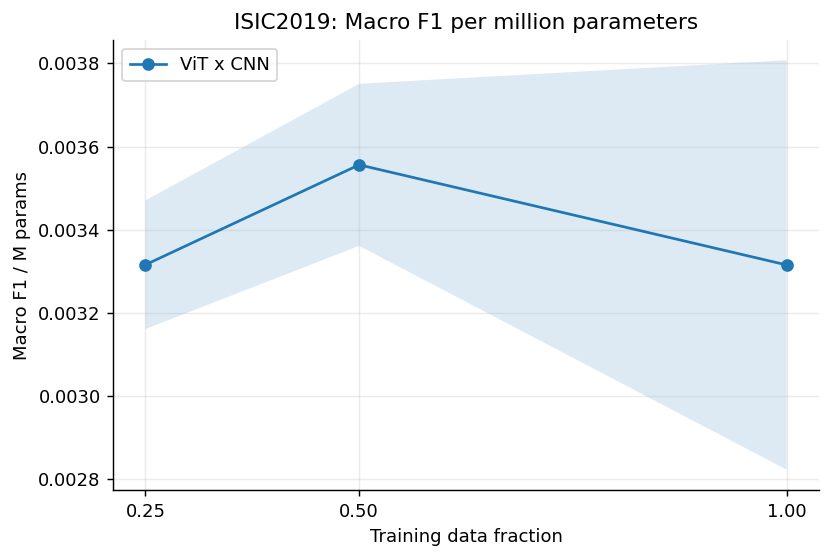

Saved: Messidor2_parameter_efficiency_macro_f1_per_mparam.png, Messidor2_parameter_efficiency_macro_f1_per_mparam.pdf


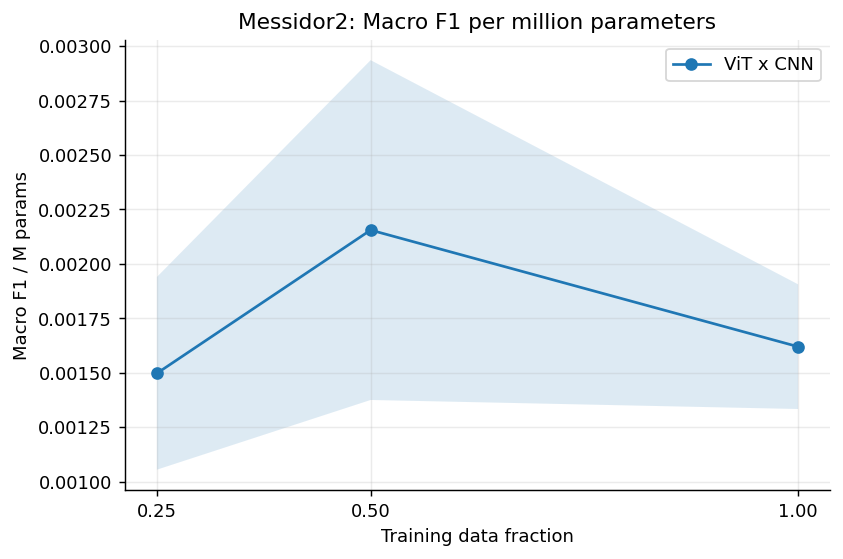

In [ ]:
for ds in DATASET_ORDER:
    sub = (
        final_df[final_df["dataset"] == ds]
        .groupby(["model","data_fraction_used"])["macro_f1_per_mparam"]
        .agg(["mean","std"])
        .reset_index()
    )
    plt.figure(figsize=(7,4.5))
    for model_name in MODEL_ORDER:
        ss = sub[sub["model"] == model_name].sort_values("data_fraction_used")
        if len(ss) == 0:
            continue
        plt.plot(ss["data_fraction_used"], ss["mean"], marker="o", label=model_name)
        plt.fill_between(
            ss["data_fraction_used"].astype(float).to_numpy(),
            (ss["mean"] - ss["std"].fillna(0)).to_numpy(),
            (ss["mean"] + ss["std"].fillna(0)).to_numpy(),
            alpha=0.15
        )
    plt.title(f"{ds}: Macro F1 per million parameters")
    plt.xlabel("Training data fraction")
    plt.ylabel("Macro F1 / M params")
    plt.xticks(FRACTION_ORDER)
    plt.legend()
    plt.grid(alpha=0.25)
    save_current_fig(f"{ds}_parameter_efficiency_macro_f1_per_mparam")
    plt.show()

## 9. Convergence and overfitting

In [ ]:
# Derive generalisation gaps at the final recorded epoch per run

if len(history_df):
    last_epoch_df = (
        history_df.sort_values(["run_id","epoch"])
        .groupby("run_id")
        .tail(1)
        .copy()
    )
    last_epoch_df["final_gap_acc"] = last_epoch_df["train_acc"] - last_epoch_df["val_acc"]
    last_epoch_df["final_gap_f1_macro"] = last_epoch_df["train_f1_macro"] - last_epoch_df["val_f1_macro"]
else:
    last_epoch_df = pd.DataFrame()

display(last_epoch_df.head())

,epoch,run_id,dataset,model,seed,data_fraction_requested,data_fraction_used,train_loss,train_acc,train_f1_macro,...,val_n_seen,val_seconds,epoch_seconds,elapsed_run_seconds,lr,best_val_loss_so_far,best_epoch_so_far,patience_counter,final_gap_acc,final_gap_f1_macro
9,10,ISIC2019_ViT x CNN_100_42,ISIC2019,ViT x CNN,42,1.00,1.00,2.122233,0.518703,0.350703,...,5067,59.809858,365.609616,3668.994281,0.000083,1.423637,5,5,-0.025801,-0.027043
21,12,ISIC2019_ViT x CNN_100_43,ISIC2019,ViT x CNN,43,1.00,1.00,2.105927,0.525365,0.351479,...,5067,60.090499,368.210961,4406.600363,0.000071,1.396187,7,5,-0.044400,-0.028233
46,25,ISIC2019_ViT x CNN_100_44,ISIC2019,ViT x CNN,44,1.00,1.00,1.867620,0.619029,0.481522,...,5067,60.214207,368.246998,9192.898439,0.000002,1.346452,22,3,0.004267,0.014118
71,25,ISIC2019_ViT x CNN_25_42,ISIC2019,ViT x CNN,42,0.25,0.25,1.878410,0.581129,0.455769,...,1267,36.758939,228.725396,5781.352047,0.000002,1.384520,21,4,0.022329,0.065877
96,25,ISIC2019_ViT x CNN_25_43,ISIC2019,ViT x CNN,43,0.25,0.25,1.892248,0.591591,0.460599,...,1267,37.442762,231.477387,5791.155577,0.000002,1.435493,21,4,0.045419,0.059674


In [ ]:
convergence_summary = (
    final_df[[
        "run_id","dataset","model","seed","data_fraction_used","best_epoch","epochs_trained","stopped_early","run_seconds"
    ]]
    .merge(
        last_epoch_df[["run_id","final_gap_acc","final_gap_f1_macro"]] if len(last_epoch_df) else pd.DataFrame(columns=["run_id"]),
        on="run_id",
        how="left"
    )
)

convergence_grouped = mean_std_summary(
    convergence_summary,
    ["dataset","model","data_fraction_used"],
    ["best_epoch","epochs_trained","stopped_early","run_seconds","final_gap_acc","final_gap_f1_macro"]
)

display(convergence_grouped)
convergence_grouped.to_csv(TABLE_DIR / "convergence_summary.csv", index=False)

,dataset,model,data_fraction_used,best_epoch_mean,best_epoch_std,best_epoch_min,best_epoch_max,best_epoch_count,epochs_trained_mean,epochs_trained_std,...,final_gap_acc_mean,final_gap_acc_std,final_gap_acc_min,final_gap_acc_max,final_gap_acc_count,final_gap_f1_macro_mean,final_gap_f1_macro_std,final_gap_f1_macro_min,final_gap_f1_macro_max,final_gap_f1_macro_count
0,ISIC2019,ViT x CNN,0.25,21.000000,0.000000,21,21,3,25.000000,0.000000,...,0.021342,0.024585,-0.003722,0.045419,3,0.048226,0.025391,0.019126,0.065877,3
1,ISIC2019,ViT x CNN,0.50,18.666667,1.527525,17,20,3,25.000000,0.000000,...,0.006457,0.007875,-0.002495,0.012316,3,0.030175,0.014413,0.013653,0.040169,3
2,ISIC2019,ViT x CNN,1.00,11.333333,9.291573,5,22,3,15.666667,8.144528,...,-0.021978,0.024557,-0.044400,0.004267,3,-0.013719,0.024115,-0.028233,0.014118,3
3,Messidor2,ViT x CNN,0.25,10.333333,11.015141,3,23,3,25.000000,0.000000,...,0.008956,0.114735,-0.123477,0.078338,3,0.077457,0.102775,-0.033880,0.168704,3
4,Messidor2,ViT x CNN,0.50,15.000000,6.244998,8,20,3,25.000000,0.000000,...,0.004365,0.053742,-0.045950,0.060979,3,0.064660,0.059106,0.000290,0.116491,3
5,Messidor2,ViT x CNN,1.00,3.666667,1.527525,2,5,3,8.666667,1.527525,...,0.109065,0.063757,0.039058,0.163799,3,0.100658,0.027797,0.075804,0.130674,3


Saved: ISIC2019_learning_curve_val_f1_macro.png, ISIC2019_learning_curve_val_f1_macro.pdf


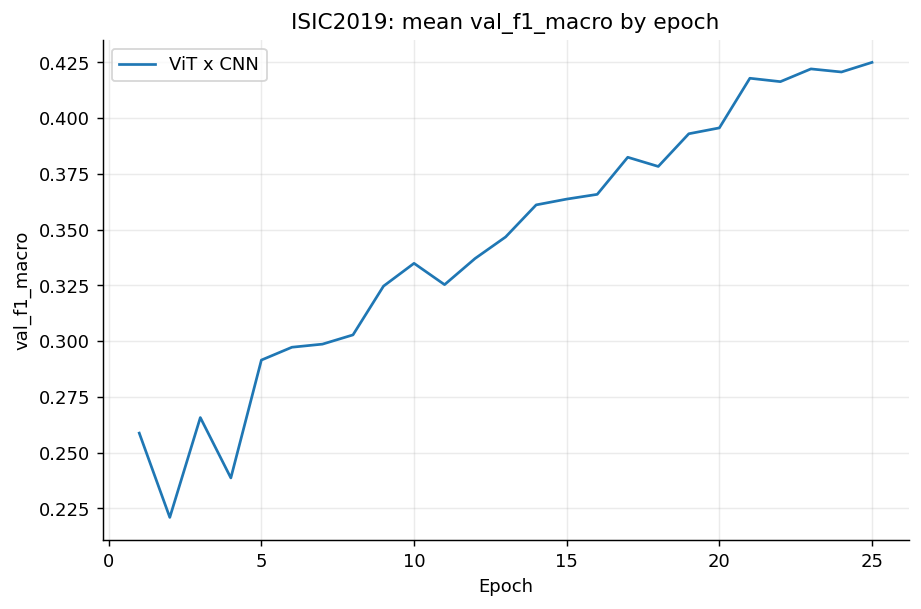

Saved: ISIC2019_learning_curve_val_loss.png, ISIC2019_learning_curve_val_loss.pdf


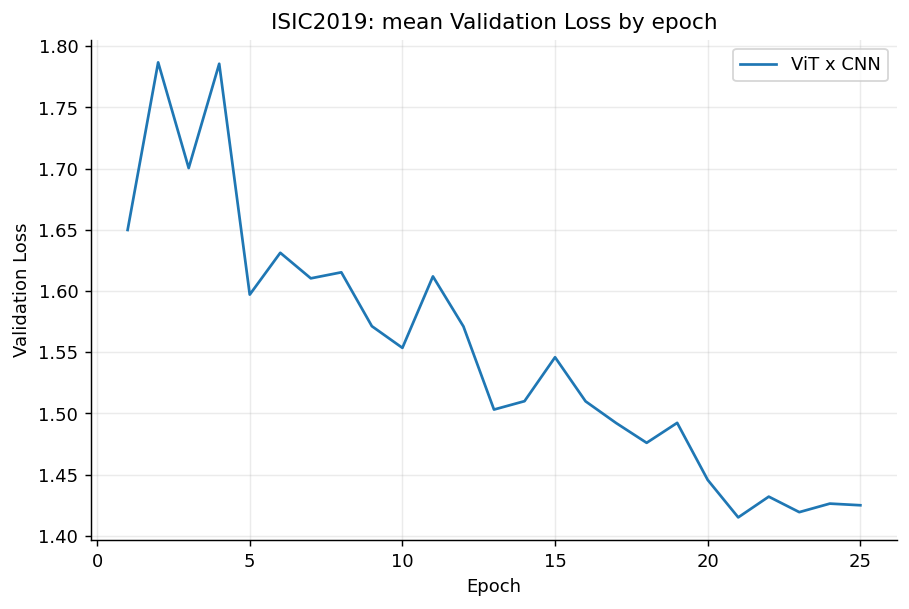

Saved: ISIC2019_learning_curve_train_loss.png, ISIC2019_learning_curve_train_loss.pdf


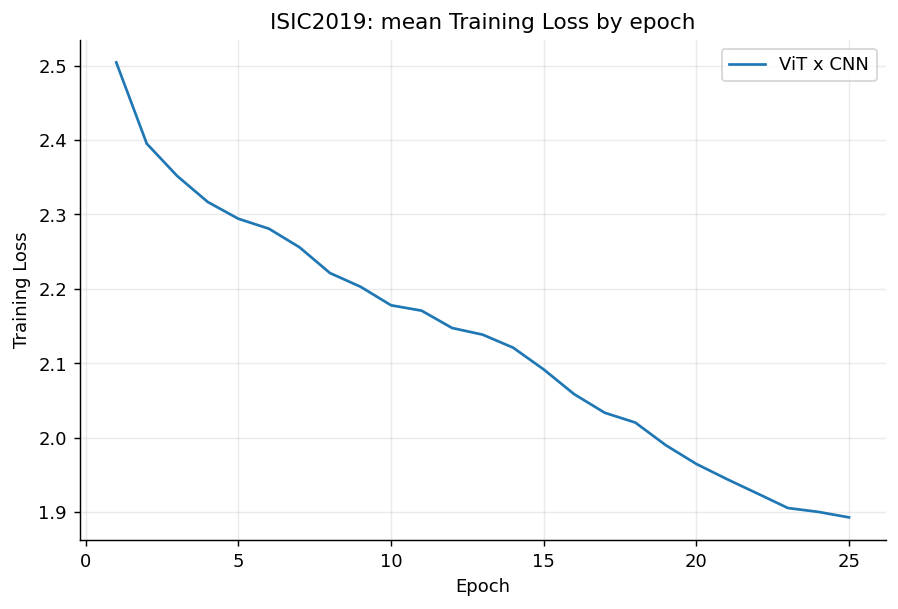

Saved: Messidor2_learning_curve_val_f1_macro.png, Messidor2_learning_curve_val_f1_macro.pdf


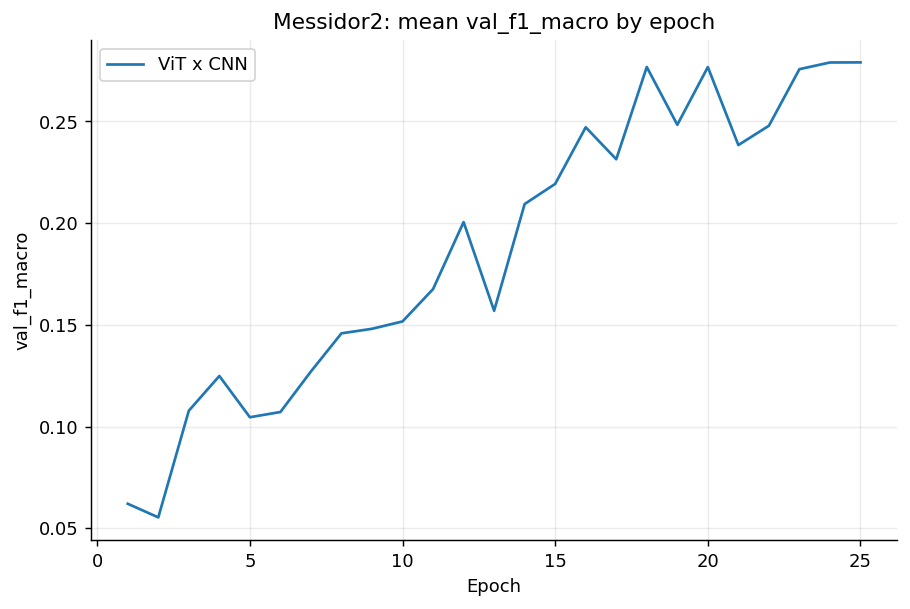

Saved: Messidor2_learning_curve_val_loss.png, Messidor2_learning_curve_val_loss.pdf


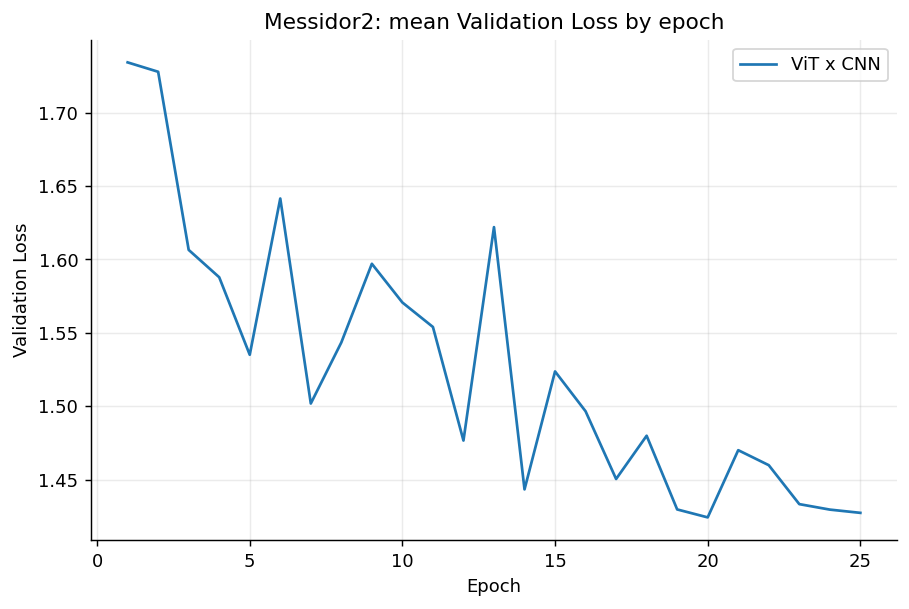

Saved: Messidor2_learning_curve_train_loss.png, Messidor2_learning_curve_train_loss.pdf


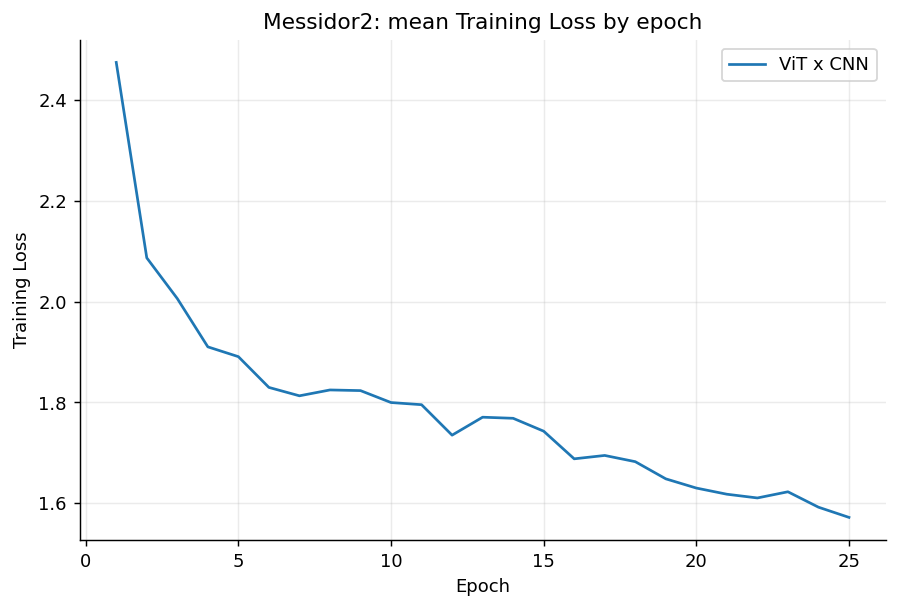

In [ ]:
def plot_learning_curves(history, dataset_name, metric="val_f1_macro", save_name=None):
    sub = history[history["dataset"] == dataset_name].copy()
    if len(sub) == 0:
        return

    plt.figure(figsize=(8,5))
    for model_name in MODEL_ORDER:
        ss = sub[sub["model"] == model_name].groupby("epoch")[metric].mean().reset_index()
        if len(ss) == 0:
            continue
        plt.plot(ss["epoch"], ss[metric], marker=None, label=model_name)
    plt.xlabel("Epoch")
    plt.ylabel(pretty_metric_name(metric))
    plt.title(f"{dataset_name}: mean {pretty_metric_name(metric)} by epoch")
    plt.legend()
    plt.grid(alpha=0.25)
    if save_name:
        save_current_fig(save_name)
    plt.show()

for ds in DATASET_ORDER:
    plot_learning_curves(history_df, ds, metric="val_f1_macro", save_name=f"{ds}_learning_curve_val_f1_macro")
    plot_learning_curves(history_df, ds, metric="val_loss", save_name=f"{ds}_learning_curve_val_loss")
    plot_learning_curves(history_df, ds, metric="train_loss", save_name=f"{ds}_learning_curve_train_loss")

Saved: ISIC2019_frac_0p25_val_f1_macro.png, ISIC2019_frac_0p25_val_f1_macro.pdf


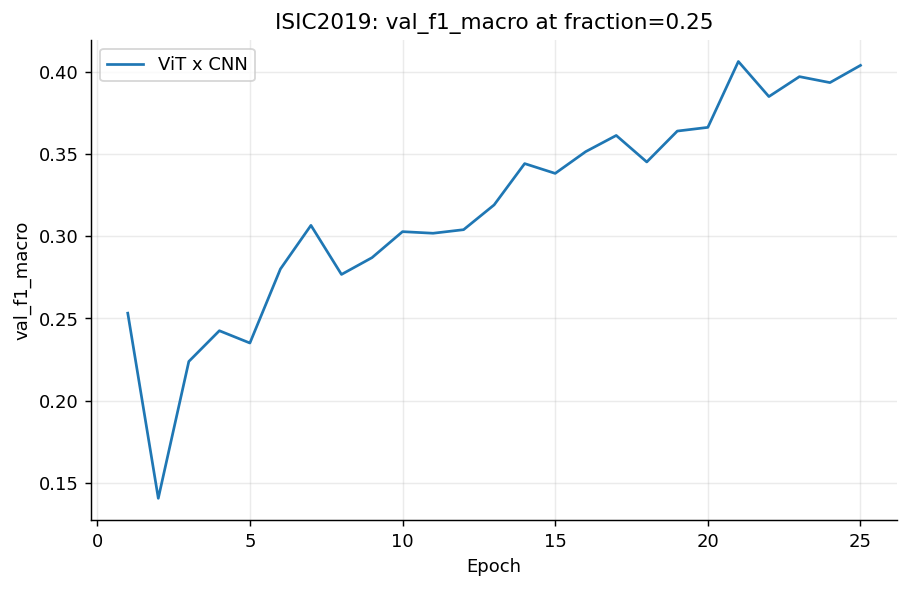

Saved: ISIC2019_frac_0p5_val_f1_macro.png, ISIC2019_frac_0p5_val_f1_macro.pdf


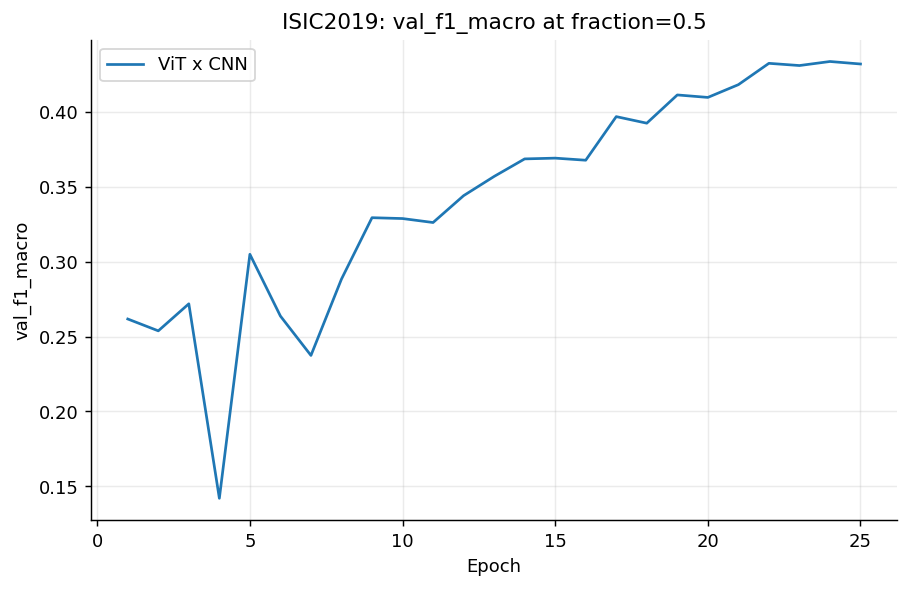

Saved: ISIC2019_frac_1p0_val_f1_macro.png, ISIC2019_frac_1p0_val_f1_macro.pdf


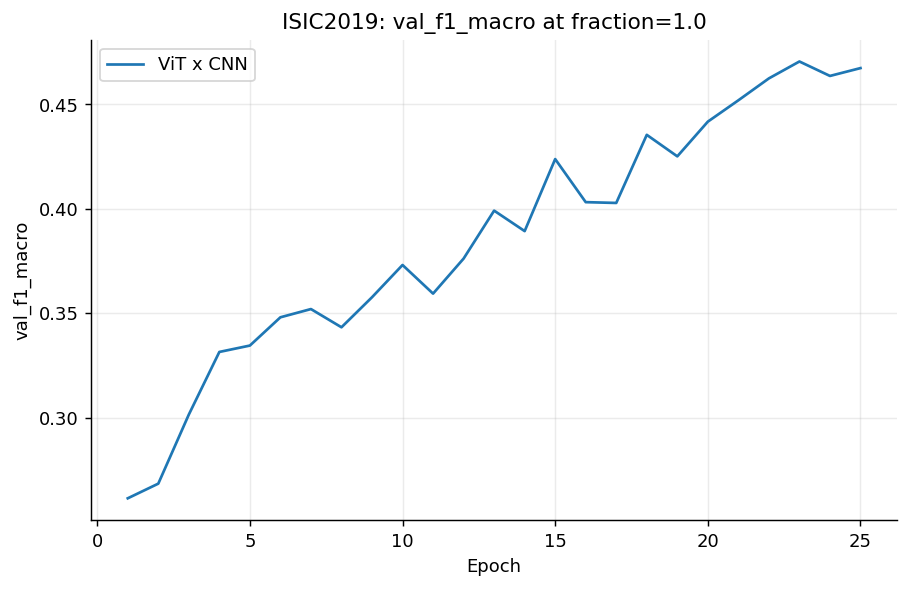

Saved: Messidor2_frac_0p25_val_f1_macro.png, Messidor2_frac_0p25_val_f1_macro.pdf


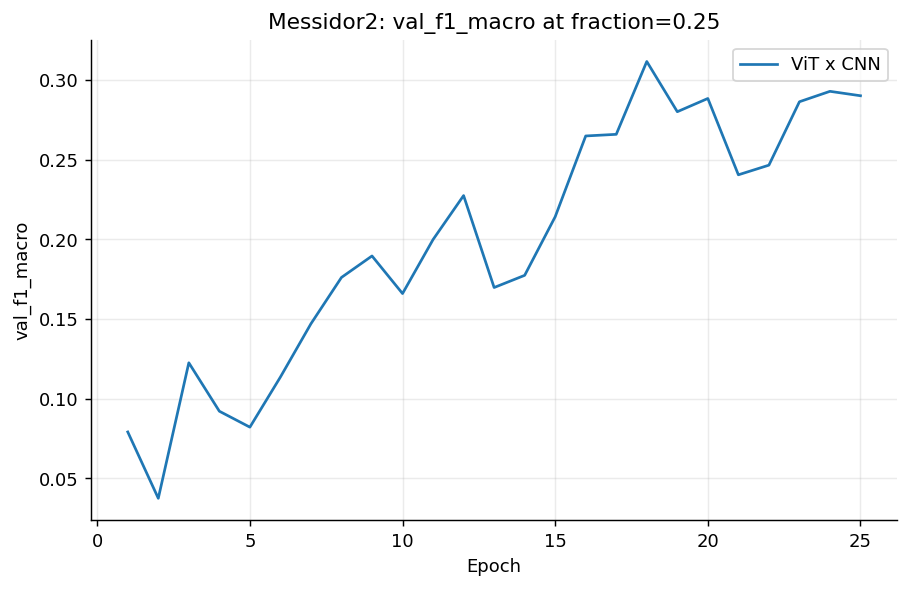

Saved: Messidor2_frac_0p5_val_f1_macro.png, Messidor2_frac_0p5_val_f1_macro.pdf


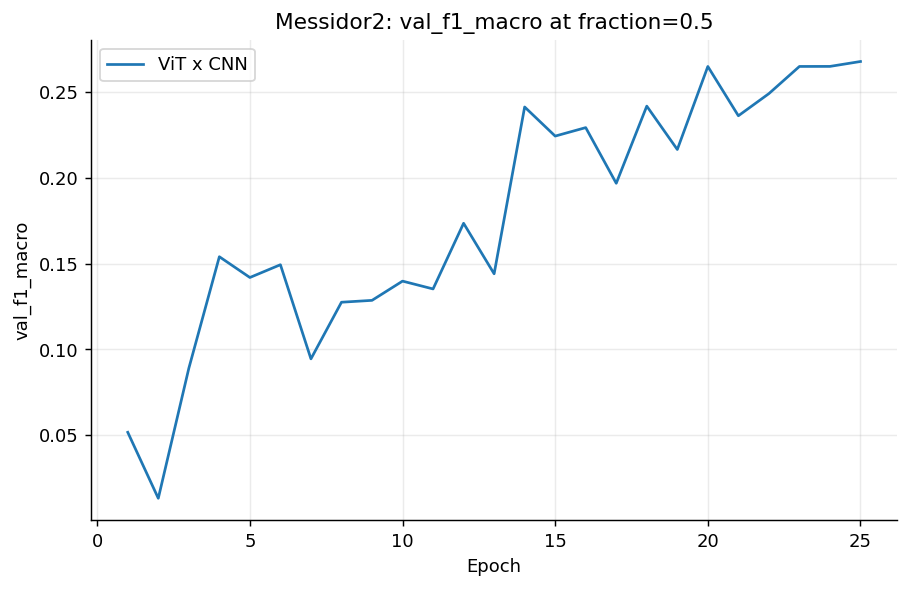

Saved: Messidor2_frac_1p0_val_f1_macro.png, Messidor2_frac_1p0_val_f1_macro.pdf


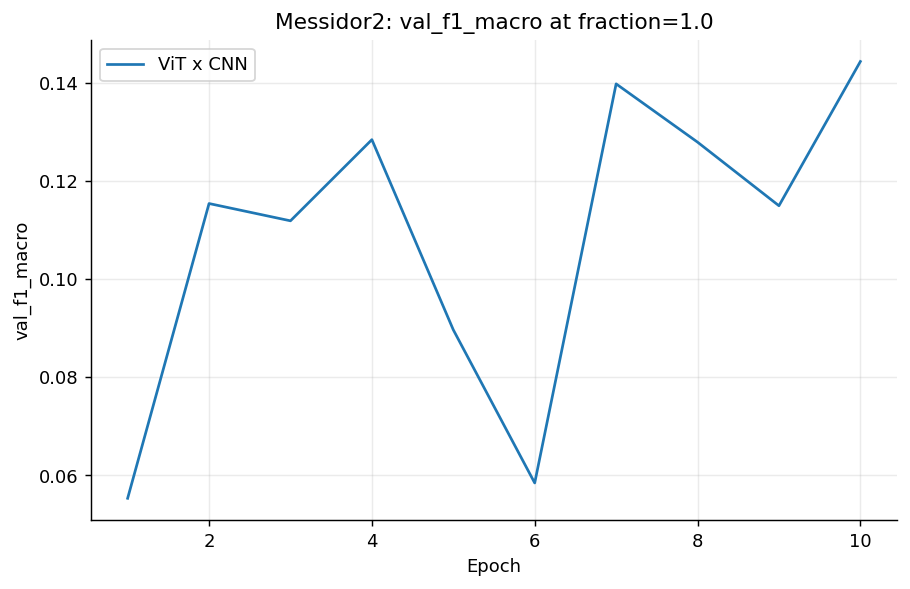

In [ ]:
# Learning curves split by fraction for finer comparison

def plot_learning_curves_by_fraction(history, dataset_name, metric="val_f1_macro"):
    sub = history[history["dataset"] == dataset_name].copy()
    fracs = sorted(sub["data_fraction_used"].dropna().unique().tolist())
    if len(sub) == 0:
        return

    for frac in fracs:
        plt.figure(figsize=(8,4.8))
        sf = sub[sub["data_fraction_used"] == frac]
        for model_name in MODEL_ORDER:
            ss = sf[sf["model"] == model_name].groupby("epoch")[metric].mean().reset_index()
            if len(ss) == 0:
                continue
            plt.plot(ss["epoch"], ss[metric], label=model_name)
        plt.title(f"{dataset_name}: {pretty_metric_name(metric)} at fraction={frac}")
        plt.xlabel("Epoch")
        plt.ylabel(pretty_metric_name(metric))
        plt.legend()
        plt.grid(alpha=0.25)
        save_current_fig(f"{dataset_name}_frac_{str(frac).replace('.','p')}_{metric}")
        plt.show()

for ds in DATASET_ORDER:
    plot_learning_curves_by_fraction(history_df, ds, metric="val_f1_macro")

## 10. Class-wise performance and confusion matrices

In [ ]:

# Per-class summary with dynamic grouping
rename_map = {}
if "f1-score" in per_class_df.columns:
    rename_map["f1-score"] = "f1_score"
if "f1" in per_class_df.columns:
    rename_map["f1"] = "f1_score"
per_class_df = per_class_df.rename(columns=rename_map)

if len(per_class_df):
    candidate_group_cols = ["dataset", "model", "data_fraction_used", "class_name", "class_id", "label"]
    group_cols = [c for c in candidate_group_cols if c in per_class_df.columns]
    metric_cols = [c for c in ["precision", "recall", "f1_score", "support"] if c in per_class_df.columns]

    if not group_cols:
        print("Per-class table exists, but no grouping columns were found.")
    elif not metric_cols:
        print("Per-class table exists, but no metric columns were found.")
    else:
        per_class_summary = mean_std_summary(per_class_df, group_cols, metric_cols)
        display(per_class_summary.head(20))
        per_class_summary.to_csv(TABLE_DIR / "per_class_summary.csv", index=False)
else:
    print("No per-class table found in saved bundles.")


,dataset,model,data_fraction_used,class_id,precision_mean,precision_std,precision_min,precision_max,precision_count,recall_mean,...,f1_score_mean,f1_score_std,f1_score_min,f1_score_max,f1_score_count,support_mean,support_std,support_min,support_max,support_count
0,ISIC2019,ViT x CNN,0.25,0,0.261075,0.012153,0.252144,0.274914,3,0.393939,...,0.313868,0.018454,0.299667,0.334728,3,374.0,0.0,374,374,3
1,ISIC2019,ViT x CNN,0.25,1,0.473546,0.022150,0.458803,0.499018,3,0.535385,...,0.502164,0.006703,0.497180,0.509784,3,975.0,0.0,975,975,3
2,ISIC2019,ViT x CNN,0.25,2,0.309323,0.057863,0.251539,0.367265,3,0.351515,...,0.320074,0.004272,0.316968,0.324946,3,660.0,0.0,660,660,3
3,ISIC2019,ViT x CNN,0.25,3,0.080912,0.020028,0.058559,0.097222,3,0.190476,...,0.113560,0.027593,0.083067,0.136808,3,91.0,0.0,91,91,3
4,ISIC2019,ViT x CNN,0.25,4,0.488841,0.021909,0.474487,0.514059,3,0.548606,...,0.515755,0.024214,0.488201,0.533641,3,1327.0,0.0,1327,1327,3
5,ISIC2019,ViT x CNN,0.25,5,0.862037,0.005997,0.855630,0.867516,3,0.582231,...,0.694534,0.023002,0.670111,0.715785,3,2495.0,0.0,2495,2495,3
6,ISIC2019,ViT x CNN,0.25,6,0.185060,0.074998,0.115108,0.264249,3,0.200000,...,0.191539,0.090037,0.105263,0.284916,3,165.0,0.0,165,165,3
7,ISIC2019,ViT x CNN,0.25,7,0.224594,0.044393,0.180180,0.268966,3,0.352564,...,0.271617,0.036460,0.245399,0.313253,3,104.0,0.0,104,104,3
8,ISIC2019,ViT x CNN,0.50,0,0.267457,0.003417,0.263551,0.269891,3,0.463458,...,0.337507,0.025753,0.310231,0.361404,3,374.0,0.0,374,374,3
9,ISIC2019,ViT x CNN,0.50,1,0.513540,0.040227,0.484467,0.559449,3,0.504615,...,0.505434,0.026633,0.479576,0.532779,3,975.0,0.0,975,975,3


In [ ]:
# Identify the best single run for each dataset x model x fraction using primary metric

best_runs = (
    final_df.sort_values(["dataset","model","data_fraction_used", PRIMARY_METRIC], ascending=[True,True,True,False])
    .groupby(["dataset","model","data_fraction_used"])
    .head(1)
    .copy()
)

display(best_runs[["run_id","dataset","model","data_fraction_used",PRIMARY_METRIC,"seed"]].sort_values(["dataset","model","data_fraction_used"]))
best_runs.to_csv(TABLE_DIR / "best_runs_by_condition.csv", index=False)

,run_id,dataset,model,data_fraction_used,test_f1_macro,seed
3,ISIC2019_ViT x CNN_25_42,ISIC2019,ViT x CNN,0.25,0.375630,42
7,ISIC2019_ViT x CNN_50_43,ISIC2019,ViT x CNN,0.50,0.416669,43
2,ISIC2019_ViT x CNN_100_44,ISIC2019,ViT x CNN,1.00,0.425481,44
14,Messidor2_ViT x CNN_25_44,Messidor2,ViT x CNN,0.25,0.219210,44
17,Messidor2_ViT x CNN_50_44,Messidor2,ViT x CNN,0.50,0.335717,44
11,Messidor2_ViT x CNN_100_44,Messidor2,ViT x CNN,1.00,0.214683,44


### ISIC2019 — ViT x CNN — fraction 0.25

Run ID: `ISIC2019_ViT x CNN_25_42`

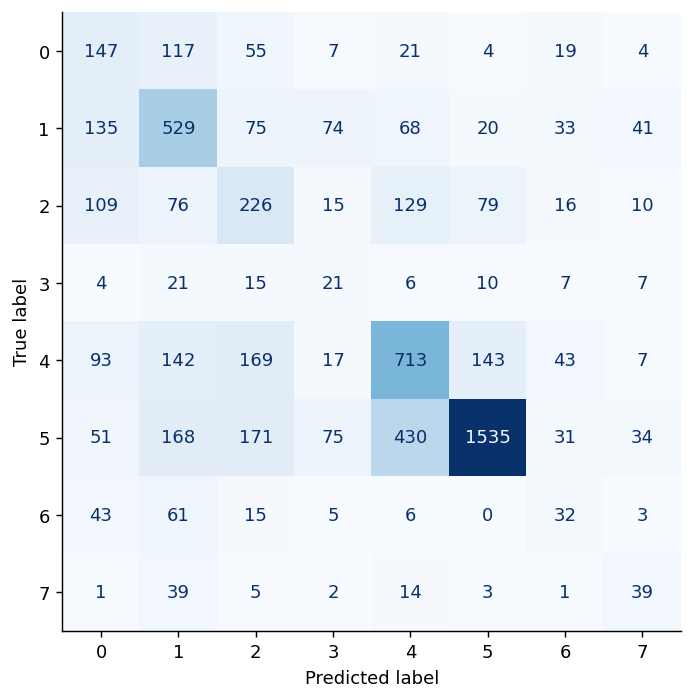

---

### ISIC2019 — ViT x CNN — fraction 0.5

Run ID: `ISIC2019_ViT x CNN_50_43`

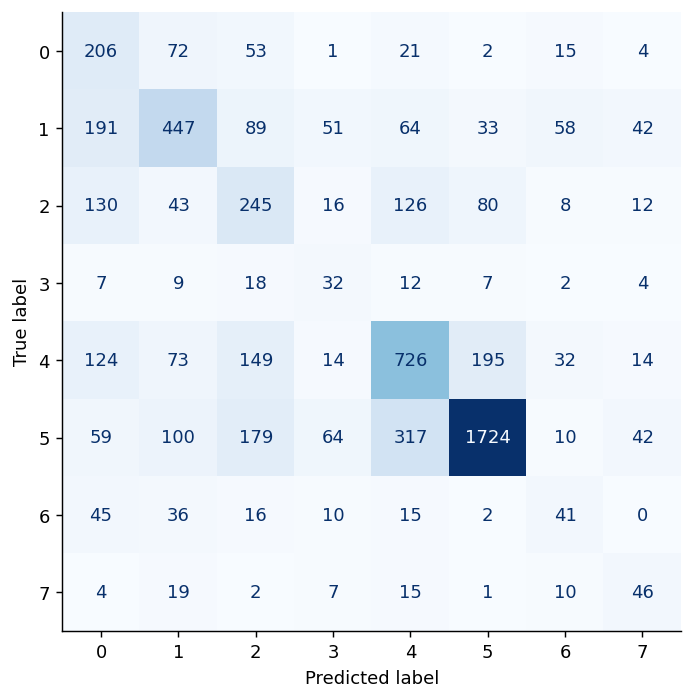

---

### ISIC2019 — ViT x CNN — fraction 1.0

Run ID: `ISIC2019_ViT x CNN_100_44`

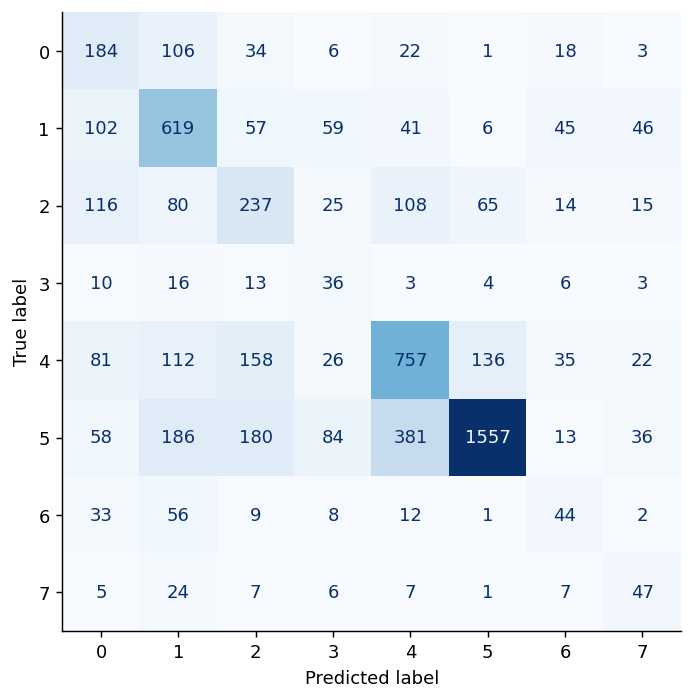

---

### Messidor2 — ViT x CNN — fraction 0.25

Run ID: `Messidor2_ViT x CNN_25_44`

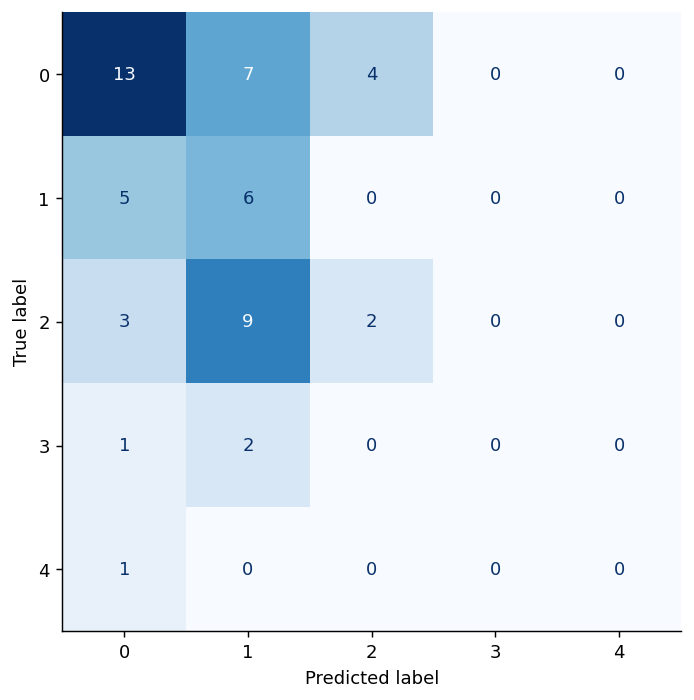

---

### Messidor2 — ViT x CNN — fraction 0.5

Run ID: `Messidor2_ViT x CNN_50_44`

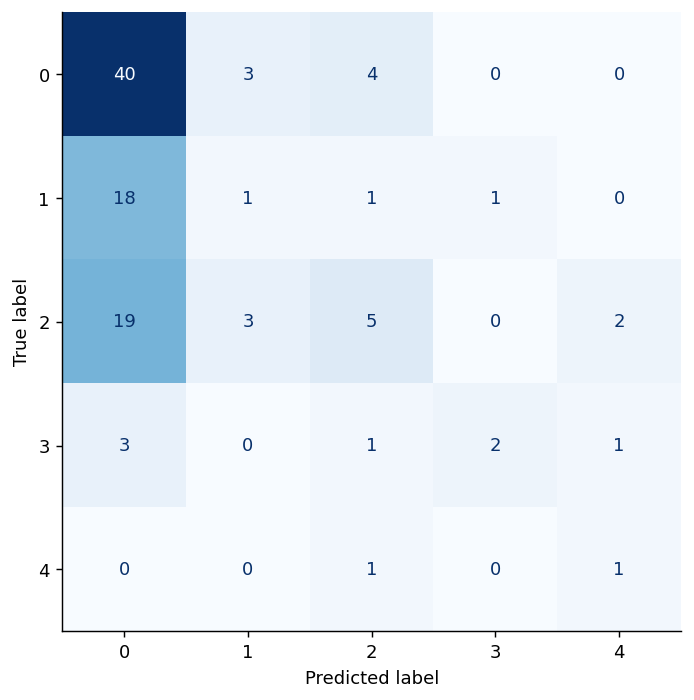

---

### Messidor2 — ViT x CNN — fraction 1.0

Run ID: `Messidor2_ViT x CNN_100_44`

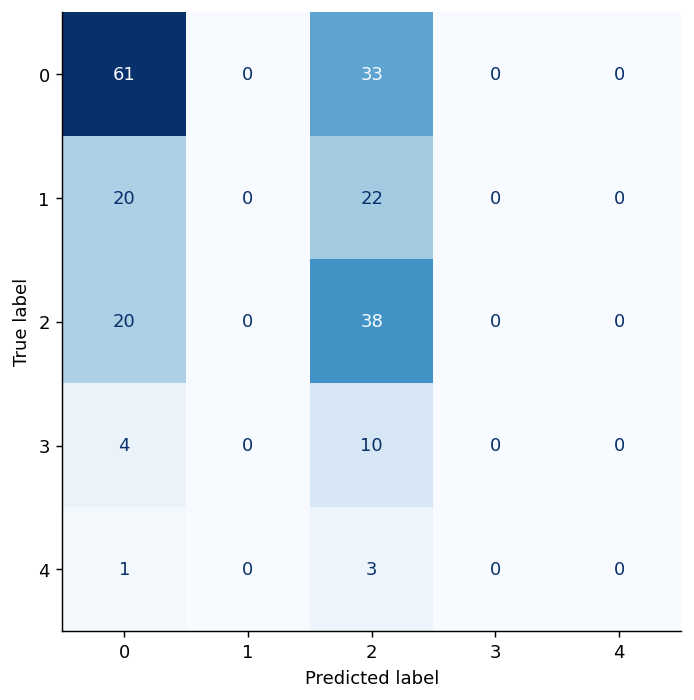

---

In [ ]:

# Plot confusion matrices for the best run in each condition

from IPython.display import Markdown, display

def plot_confusion_for_run(run_id):
    cm = confusion_store.get(run_id)
    if cm is None:
        print(f"No confusion matrix stored for {run_id}")
        return

    fig, ax = plt.subplots(figsize=(6.8, 5.8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title("")
    ax.grid(False)
    plt.tight_layout(pad=2.2)
    plt.show()
    plt.close(fig)

sort_cols = [c for c in ["dataset", "data_fraction_used", "model"] if c in best_runs.columns]
plot_rows = best_runs.sort_values(sort_cols) if len(best_runs) and sort_cols else best_runs

for _, row in plot_rows.iterrows():
    header = f"### {row.get('dataset', 'NA')} — {row.get('model', 'NA')} — fraction {row.get('data_fraction_used', 'NA')}"
    subline = f"Run ID: `{row.get('run_id', 'NA')}`"
    display(Markdown(f"""{header}

{subline}"""))
    plot_confusion_for_run(row["run_id"])
    print()
    display(Markdown("---"))
    print()


## 11. Explainability outputs

This notebook focuses on the comparison tables, metrics, and plots for the saved Hybrid CNN-ViT runs.


## 13. Combined summary table

In [ ]:
chapter_table = (
    final_df.groupby(["dataset","model","data_fraction_used"])
    .agg(
        n_runs=("run_id","nunique"),
        macro_f1_mean=("test_f1_macro","mean"),
        macro_f1_std=("test_f1_macro","std"),
        auroc_mean=("test_auroc_ovr","mean"),
        auroc_std=("test_auroc_ovr","std"),
        acc_mean=("test_acc","mean"),
        acc_std=("test_acc","std"),
        params_m=("params_millions","mean"),
        macro_f1_per_mparam_mean=("macro_f1_per_mparam","mean"),
        best_epoch_mean=("best_epoch","mean"),
        epochs_trained_mean=("epochs_trained","mean"),
        stopped_early_rate=("stopped_early","mean"),
        run_seconds_mean=("run_seconds","mean"),
    )
    .reset_index()
    .sort_values(["dataset","model","data_fraction_used"])
)

for c in ["macro_f1_mean","macro_f1_std","auroc_mean","auroc_std","acc_mean","acc_std","params_m","macro_f1_per_mparam_mean","best_epoch_mean","epochs_trained_mean","stopped_early_rate","run_seconds_mean"]:
    chapter_table[c] = chapter_table[c].round(4)

display(chapter_table)
chapter_table.to_csv(TABLE_DIR / "hybrid_chapter_master_table.csv", index=False)

,dataset,model,data_fraction_used,n_runs,macro_f1_mean,macro_f1_std,auroc_mean,auroc_std,acc_mean,acc_std,params_m,macro_f1_per_mparam_mean,best_epoch_mean,epochs_trained_mean,stopped_early_rate,run_seconds_mean
0,ISIC2019,ViT x CNN,0.25,3,0.3654,0.0170,0.7985,0.0044,0.5119,0.0184,110.2022,0.0033,21.0000,25.0000,0.0000,6028.2394
1,ISIC2019,ViT x CNN,0.50,3,0.3919,0.0215,0.8162,0.0020,0.5405,0.0173,110.2022,0.0036,18.6667,25.0000,0.0000,9392.4607
2,ISIC2019,ViT x CNN,1.00,3,0.3653,0.0543,0.8048,0.0225,0.5418,0.0190,110.2022,0.0033,11.3333,15.6667,0.6667,5898.5897
3,Messidor2,ViT x CNN,0.25,3,0.1651,0.0487,0.5968,0.0502,0.4403,0.0393,110.1999,0.0015,10.3333,25.0000,0.0000,328.6598
4,Messidor2,ViT x CNN,0.50,3,0.2375,0.0860,0.7080,0.0339,0.4591,0.0054,110.1999,0.0022,15.0000,25.0000,0.0000,583.2025
5,Messidor2,ViT x CNN,1.00,3,0.1785,0.0315,0.6712,0.0059,0.4324,0.0300,110.1999,0.0016,3.6667,8.6667,1.0000,408.9748


## 14. Export cleaned tables

In [ ]:
export_targets = {
    "final_df.csv": final_df,
    "history_df.csv": history_df,
    "per_class_df.csv": per_class_df,
    "pred_df.csv": pred_df,
    "split_df.csv": split_df,
}

for filename, df in export_targets.items():
    path = TABLE_DIR / filename
    df.to_csv(path, index=False)
    print(f"Saved {path}")

Saved /content/drive/MyDrive/MSC_Research/Hybrids/Analysis_Tables/final_df.csv
Saved /content/drive/MyDrive/MSC_Research/Hybrids/Analysis_Tables/history_df.csv
Saved /content/drive/MyDrive/MSC_Research/Hybrids/Analysis_Tables/per_class_df.csv
Saved /content/drive/MyDrive/MSC_Research/Hybrids/Analysis_Tables/pred_df.csv
Saved /content/drive/MyDrive/MSC_Research/Hybrids/Analysis_Tables/split_df.csv


## 15. Writing checklist

## 16. Additional filtered class analysis

In [ ]:
# Additional analysis settings

TOP_ISIC_K = 4
TOP_CHOSEN_K = 3

available_datasets = sorted(final_df["dataset"].dropna().astype(str).unique().tolist()) if "dataset" in final_df.columns else []
available_models = sorted(final_df["model"].dropna().astype(str).unique().tolist()) if "model" in final_df.columns else []

messidor2_candidates = ["MESSIDOR2", "Messidor2", "messidor2"]
CHOSEN_DATASET = next((d for d in messidor2_candidates if d in available_datasets), None)
if CHOSEN_DATASET is None:
    CHOSEN_DATASET = available_datasets[0] if available_datasets else None

preferred_models = ["hybrid_cnn_vit_small", "HYBRID_CNN_VIT_SMALL", "vit_base_resnet50d_224", "VIT_BASE_RESNET50D_224"]
CHOSEN_MODEL = next((m for m in preferred_models if m in available_models), None)
if CHOSEN_MODEL is None:
    CHOSEN_MODEL = available_models[0] if available_models else None

print("CHOSEN_DATASET =", CHOSEN_DATASET)
print("CHOSEN_MODEL   =", CHOSEN_MODEL)
print("Top 3 classes are for Messidor2.")


CHOSEN_DATASET = Messidor2
CHOSEN_MODEL   = ViT x CNN
Top 3 classes are for Messidor2.


In [ ]:

# Filtered-class helpers

from sklearn.metrics import confusion_matrix, classification_report

def _pick_existing(df, candidates):
    return next((c for c in candidates if c in df.columns), None)

TRUE_COL = _pick_existing(pred_df, ["true_label", "label", "target", "y_true"])
PRED_COL = _pick_existing(pred_df, ["pred_label", "prediction", "y_pred"])
PRED_SPLIT_COL = _pick_existing(pred_df, ["pred_split", "split", "saved_split_name"])

ATTN_TRUE_COL = _pick_existing(attention_df, ["true_label", "label", "target", "class_id"])
ATTN_PRED_COL = _pick_existing(attention_df, ["pred_label", "prediction", "y_pred"])

CLASS_NAME_COL = _pick_existing(per_class_df, ["class_name", "label", "class_label"])
CLASS_ID_COL = _pick_existing(per_class_df, ["class_id", "true_label", "label_id"])

def build_class_name_map():
    maps = {}
    if len(per_class_df) == 0:
        return maps
    if CLASS_ID_COL is None:
        return maps
    name_col = CLASS_NAME_COL if CLASS_NAME_COL in per_class_df.columns else None
    for ds, sub in per_class_df.groupby("dataset", dropna=False):
        ds_map = {}
        for _, row in sub.dropna(subset=[CLASS_ID_COL]).iterrows():
            cid = row.get(CLASS_ID_COL)
            if pd.isna(cid):
                continue
            try:
                cid = int(cid)
            except Exception:
                continue
            name_val = row.get(name_col) if name_col else None
            if pd.notna(name_val):
                ds_map[cid] = str(name_val)
        maps[ds] = ds_map
    return maps

CLASS_NAME_MAPS = build_class_name_map()

def label_to_name(dataset, class_id):
    try:
        class_id = int(class_id)
    except Exception:
        return str(class_id)
    return CLASS_NAME_MAPS.get(dataset, {}).get(class_id, str(class_id))

def get_top_classes(dataset, model=None, k=3):
    sub = pred_df.copy()
    if dataset is not None and "dataset" in sub.columns:
        sub = sub[sub["dataset"] == dataset]
    if model is not None and "model" in sub.columns:
        sub = sub[sub["model"] == model]
    if PRED_SPLIT_COL in sub.columns:
        sub = sub[sub[PRED_SPLIT_COL] == "test"]
    if TRUE_COL is None or len(sub) == 0:
        return []
    return (
        sub[TRUE_COL].value_counts()
        .sort_values(ascending=False)
        .head(k)
        .index.astype(int)
        .tolist()
    )

def classification_table_from_predictions(dataset, model=None, classes=None):
    sub = pred_df.copy()
    if dataset is not None and "dataset" in sub.columns:
        sub = sub[sub["dataset"] == dataset]
    if model is not None and "model" in sub.columns:
        sub = sub[sub["model"] == model]
    if PRED_SPLIT_COL in sub.columns:
        sub = sub[sub[PRED_SPLIT_COL] == "test"]
    if TRUE_COL is None or PRED_COL is None or len(sub) == 0:
        return pd.DataFrame()
    if classes is not None:
        sub = sub[sub[TRUE_COL].isin(classes) & sub[PRED_COL].isin(classes)]
    if len(sub) == 0:
        return pd.DataFrame()

    y_true = sub[TRUE_COL].astype(int)
    y_pred = sub[PRED_COL].astype(int)
    labels = sorted(classes) if classes is not None else sorted(pd.unique(pd.concat([y_true, y_pred])))
    rep = classification_report(
        y_true, y_pred, labels=labels, output_dict=True, zero_division=0
    )
    rows = []
    for cid in labels:
        row = rep.get(str(cid), {})
        rows.append({
            "dataset": dataset,
            "model": model,
            "class_id": cid,
            "class_name": label_to_name(dataset, cid),
            "precision": row.get("precision", np.nan),
            "recall": row.get("recall", np.nan),
            "f1_score": row.get("f1-score", np.nan),
            "support": row.get("support", np.nan),
        })
    return pd.DataFrame(rows)

def plot_filtered_confusions(dataset, model=None, classes=None, max_runs=12):
    sub = best_runs.copy()
    if dataset is not None and "dataset" in sub.columns:
        sub = sub[sub["dataset"] == dataset]
    if model is not None and "model" in sub.columns:
        sub = sub[sub["model"] == model]
    sub = sub.sort_values([c for c in ["dataset", "model", "data_fraction_used"] if c in sub.columns]).head(max_runs)
    if len(sub) == 0:
        print("No matching best runs found.")
        return pd.DataFrame()

    plotted = []
    for _, row in sub.iterrows():
        run_id = row["run_id"]
        run_pred = pred_df[pred_df["run_id"] == run_id].copy()
        if PRED_SPLIT_COL in run_pred.columns:
            run_pred = run_pred[run_pred[PRED_SPLIT_COL] == "test"]
        if TRUE_COL is None or PRED_COL is None or len(run_pred) == 0:
            continue
        if classes is not None:
            run_pred = run_pred[run_pred[TRUE_COL].isin(classes) & run_pred[PRED_COL].isin(classes)]
        if len(run_pred) == 0:
            continue
        labels = sorted(classes) if classes is not None else sorted(pd.unique(pd.concat([run_pred[TRUE_COL], run_pred[PRED_COL]])))
        cm = confusion_matrix(run_pred[TRUE_COL].astype(int), run_pred[PRED_COL].astype(int), labels=labels)

        fig, ax = plt.subplots(figsize=(6.8, 5.8))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[label_to_name(dataset, x) for x in labels])
        disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d", xticks_rotation=45)
        ax.set_title(f"{row.get('dataset', 'NA')} — {row.get('model', 'NA')} — fraction {row.get('data_fraction_used', 'NA')}")
        ax.grid(False)
        plt.tight_layout(pad=2.2)
        plt.show()
        plt.close(fig)

        plotted.append({
            "run_id": run_id,
            "dataset": row.get("dataset"),
            "model": row.get("model"),
            "data_fraction_used": row.get("data_fraction_used"),
            "n_classes": len(labels),
        })
    return pd.DataFrame(plotted)


## 17. Top 4 classes for ISIC

,class_id,class_name
0,5,5
1,4,4
2,1,1
3,2,2


,dataset,model,class_id,class_name,precision,recall,f1_score,support
3,ISIC2019,None,5,5,0.841725,0.690829,0.758849,20762.0
2,ISIC2019,None,4,4,0.542580,0.618316,0.577978,10603.0
0,ISIC2019,None,1,1,0.614212,0.720900,0.663293,6091.0
1,ISIC2019,None,2,2,0.346127,0.435217,0.385593,4600.0


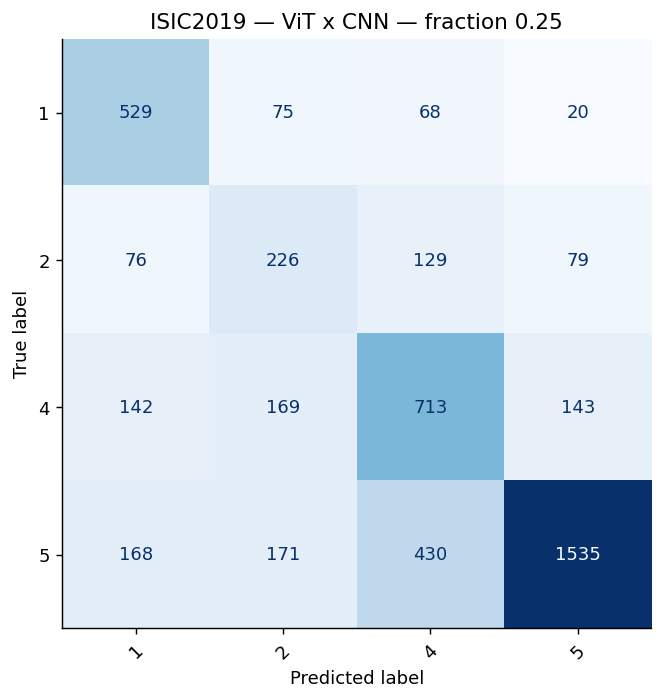

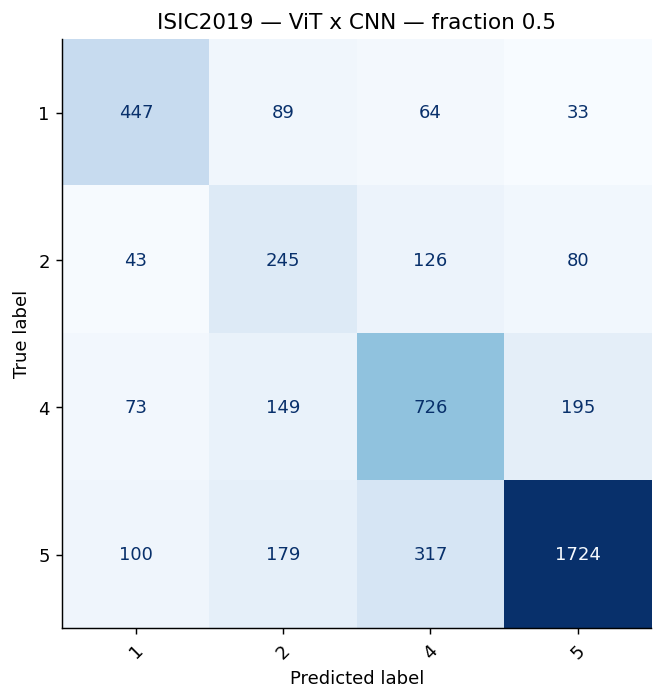

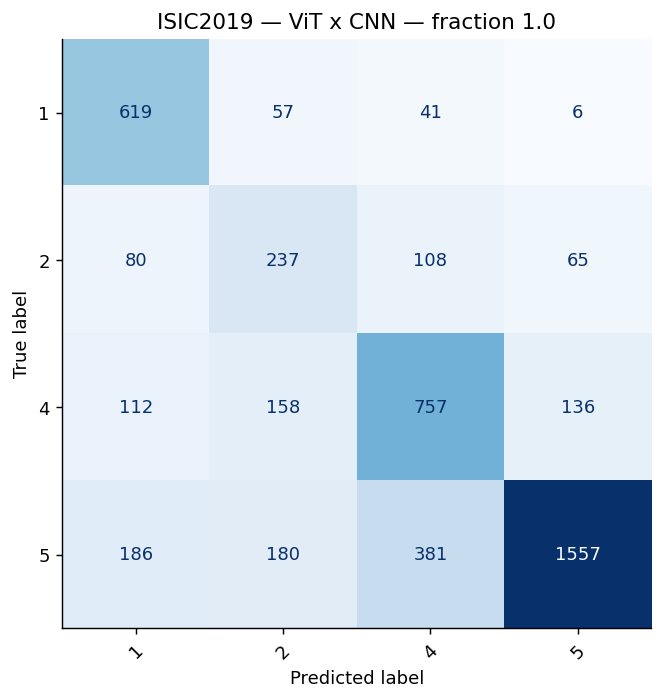

In [ ]:

ISIC_DATASET_NAME = "ISIC2019" if "ISIC2019" in available_datasets else ("isic2019" if "isic2019" in available_datasets else None)

if ISIC_DATASET_NAME is None:
    print("ISIC dataset was not found in final_df.")
else:
    isic_top_classes = get_top_classes(dataset=ISIC_DATASET_NAME, model=None, k=TOP_ISIC_K)
    isic_top_class_table = pd.DataFrame({
        "class_id": isic_top_classes,
        "class_name": [label_to_name(ISIC_DATASET_NAME, x) for x in isic_top_classes]
    })
    display(isic_top_class_table)

    isic_filtered_per_class = classification_table_from_predictions(
        dataset=ISIC_DATASET_NAME,
        model=None,
        classes=isic_top_classes,
    )
    if len(isic_filtered_per_class):
        display(isic_filtered_per_class.sort_values("support", ascending=False))
        isic_filtered_per_class.to_csv(TABLE_DIR / "isic_top4_per_class_table.csv", index=False)

    isic_filtered_runs = plot_filtered_confusions(
        dataset=ISIC_DATASET_NAME,
        model=None,
        classes=isic_top_classes,
        max_runs=12,
    )
    if isinstance(isic_filtered_runs, pd.DataFrame) and len(isic_filtered_runs):
        isic_filtered_runs.to_csv(TABLE_DIR / "isic_top4_confusion_runs.csv", index=False)


## 18. Top 3 classes for Messidor2

,class_id,class_name
0,0,0
1,2,2
2,1,1


,dataset,model,class_id,class_name,precision,recall,f1_score,support
0,Messidor2,ViT x CNN,0,0,0.528160,0.886555,0.661961,476.0
2,Messidor2,ViT x CNN,2,2,0.411765,0.181481,0.251928,270.0
1,Messidor2,ViT x CNN,1,1,0.228571,0.038647,0.066116,207.0


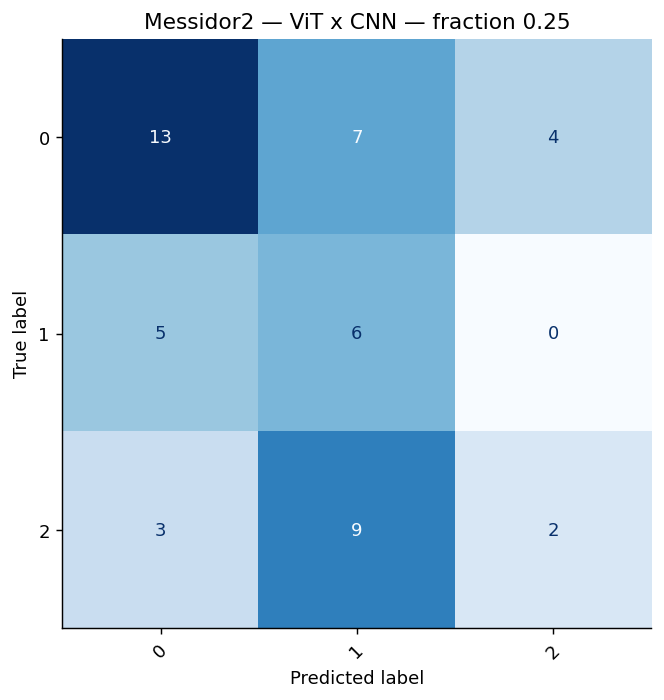

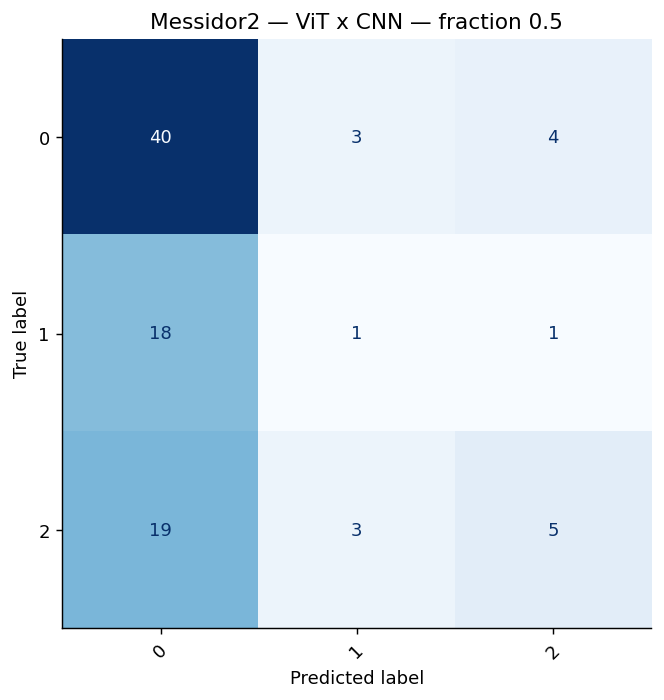

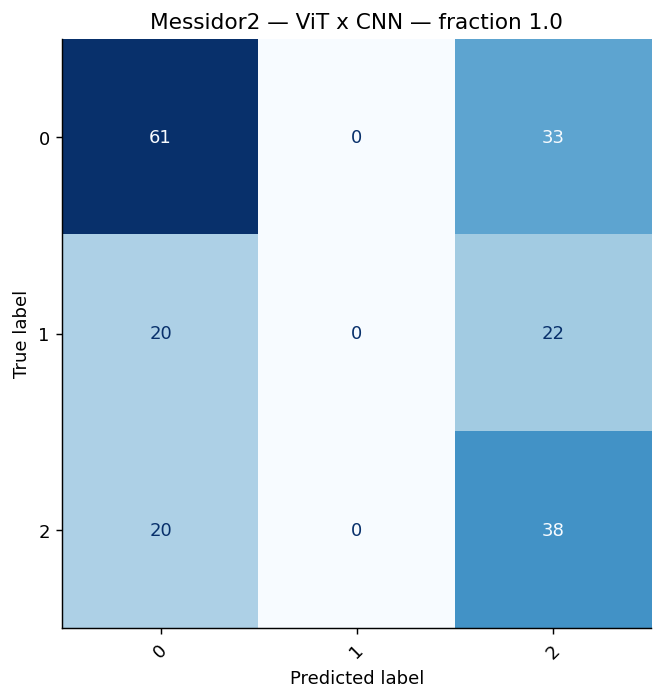

In [ ]:
if CHOSEN_DATASET is None or CHOSEN_MODEL is None:
    print("Set CHOSEN_DATASET and CHOSEN_MODEL in the settings cell above.")
else:
    chosen_top_classes = get_top_classes(dataset=CHOSEN_DATASET, model=CHOSEN_MODEL, k=TOP_CHOSEN_K)
    chosen_top_class_table = pd.DataFrame({
        "class_id": chosen_top_classes,
        "class_name": [label_to_name(CHOSEN_DATASET, x) for x in chosen_top_classes]
    })
    display(chosen_top_class_table)

    chosen_filtered_per_class = classification_table_from_predictions(
        dataset=CHOSEN_DATASET,
        model=CHOSEN_MODEL,
        classes=chosen_top_classes,
    )
    if len(chosen_filtered_per_class):
        display(chosen_filtered_per_class.sort_values("support", ascending=False))
        chosen_filtered_per_class.to_csv(
            TABLE_DIR / f"{CHOSEN_DATASET}_{CHOSEN_MODEL}_top3_per_class_table.csv",
            index=False,
        )
    else:
        print(f"No filtered per-class table produced for dataset={CHOSEN_DATASET}, model={CHOSEN_MODEL}.")

    chosen_filtered_runs = plot_filtered_confusions(
        dataset=CHOSEN_DATASET,
        model=CHOSEN_MODEL,
        classes=chosen_top_classes,
        max_runs=12,
    )
    if isinstance(chosen_filtered_runs, pd.DataFrame) and len(chosen_filtered_runs):
        chosen_filtered_runs.to_csv(
            TABLE_DIR / f"{CHOSEN_DATASET}_{CHOSEN_MODEL}_top3_confusion_runs.csv",
            index=False,
        )

In [ ]:
# ========= FINAL COPYABLE SUMMARY CELL =========
# Change this per notebook:
# NOTEBOOK_LABEL = "CNN_Comparison_Analysis_V5"
# NOTEBOOK_LABEL = "ViT_Comparison_Analysis_V4"
NOTEBOOK_LABEL = "Hybrid_Comparison_Analysis_V1"

from pathlib import Path
from IPython.display import display
import pandas as pd
import numpy as np
import io
import contextlib

def _print_section(title):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)

def _safe_exists(name):
    return name in globals() and globals()[name] is not None

def _as_df(obj):
    return isinstance(obj, pd.DataFrame)

def _fmt_df_for_print(df, max_rows=200, max_cols=50, index=False):
    if df is None or len(df) == 0:
        return "[empty]"
    with pd.option_context(
        "display.max_rows", max_rows,
        "display.max_columns", max_cols,
        "display.width", 200,
        "display.max_colwidth", 120,
        "display.float_format", lambda x: f"{x:.4f}" if isinstance(x, (float, np.floating)) else str(x),
    ):
        return df.to_string(index=index)

def _collect_plot_names():
    plot_names = []

    # 1) Best source: files actually saved through save_current_fig into FIG_DIR
    if _safe_exists("FIG_DIR"):
        fig_dir = Path(FIG_DIR)
        if fig_dir.exists():
            pngs = sorted(fig_dir.glob("*.png"))
            pdfs = sorted(fig_dir.glob("*.pdf"))

            if pngs:
                plot_names.extend([p.stem for p in pngs])

            # if only pdfs exist, add those stems too
            if not plot_names and pdfs:
                plot_names.extend([p.stem for p in pdfs])

    # 2) Fallback: reconstruct common names from notebook variables if files are not yet present
    if not plot_names:
        dataset_order = globals().get("DATASET_ORDER", [])
        fraction_order = globals().get("FRACTION_ORDER", [])

        # main metric-vs-fraction plots
        primary_metric = globals().get("PRIMARY_METRIC", None)
        secondary_metrics = globals().get("SECONDARY_METRICS", [])
        metrics = [m for m in [primary_metric] + list(secondary_metrics) if m]

        for ds in dataset_order:
            for metric in metrics:
                plot_names.append(f"{ds}_{metric}_vs_fraction")

        # parameter efficiency
        if _safe_exists("param_eff_df"):
            for ds in dataset_order:
                plot_names.append(f"{ds}_parameter_efficiency_macro_f1_per_mparam")

        # learning curves
        if _safe_exists("history_df"):
            for ds in dataset_order:
                plot_names.append(f"{ds}_learning_curve_val_f1_macro")
                plot_names.append(f"{ds}_learning_curve_val_loss")
                plot_names.append(f"{ds}_learning_curve_train_loss")
                for frac in fraction_order:
                    frac_name = str(frac).replace(".", "p")
                    plot_names.append(f"{ds}_frac_{frac_name}_val_f1_macro")

        # filtered confusion outputs are shown inline, not always saved with a stable filename
        if _safe_exists("best_runs"):
            plot_names.append("best_run_confusion_matrices_inline")

        if _safe_exists("isic_filtered_runs"):
            plot_names.append("isic_topk_filtered_confusions_inline")

        if _safe_exists("chosen_filtered_runs"):
            plot_names.append("chosen_dataset_topk_filtered_confusions_inline")

    plot_names = sorted(set(plot_names))
    return plot_names

def _print_metric_overview():
    if not _safe_exists("final_df") or not _as_df(final_df):
        print("final_df not found.")
        return

    _print_section("1) RAW RUN-LEVEL METRICS (final_df)")

    preferred_cols = [
        "run_id", "dataset", "model", "seed", "data_fraction_used",
        "test_f1_macro", "test_acc", "test_balanced_acc", "test_auroc_ovr", "test_loss",
        "best_epoch", "epochs_trained", "stopped_early", "run_seconds",
        "total_params", "params_millions", "macro_f1_per_mparam", "auroc_per_mparam"
    ]
    existing_cols = [c for c in preferred_cols if c in final_df.columns]
    extra_metric_cols = [
        c for c in final_df.columns
        if c not in existing_cols and (
            "test_" in c or "val_" in c or "train_" in c or
            "epoch" in c or "loss" in c or "acc" in c or "f1" in c or
            "auc" in c or "auroc" in c or "precision" in c or "recall" in c
        )
    ]
    cols_to_show = existing_cols + extra_metric_cols[:20]

    printable_df = final_df[cols_to_show].copy() if cols_to_show else final_df.copy()
    print(_fmt_df_for_print(printable_df, max_rows=min(500, max(50, len(printable_df))), index=False))

    numeric_cols = final_df.select_dtypes(include=[np.number]).columns.tolist()
    if numeric_cols:
        _print_section("2) NUMERIC METRIC SUMMARY (mean/std/min/max)")
        summary = final_df[numeric_cols].agg(["mean", "std", "min", "max"]).T.reset_index()
        summary = summary.rename(columns={"index": "metric"})
        print(_fmt_df_for_print(summary, max_rows=500, index=False))

def _print_saved_tables():
    candidate_tables = [
        "summary_main",
        "compact_main",
        "gain_df",
        "curve_df",
        "pairwise_df",
        "param_eff_df",
        "convergence_summary",
        "convergence_grouped",
        "per_class_summary",
        "best_runs",
        "chapter_table",
        "isic_top_class_table",
        "isic_filtered_per_class",
        "isic_filtered_runs",
        "chosen_top_class_table",
        "chosen_filtered_per_class",
        "chosen_filtered_runs",
    ]

    found_any = False
    for name in candidate_tables:
        if _safe_exists(name) and _as_df(globals()[name]):
            df = globals()[name]
            found_any = True
            _print_section(f"TABLE: {name}  |  shape={df.shape}")
            print(_fmt_df_for_print(df, max_rows=min(300, max(30, len(df))), index=False))

    if not found_any:
        _print_section("TABLES")
        print("No recognised summary tables were found in globals().")

def _build_full_report():
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        print("#" * 100)
        print(f"NOTEBOOK SUMMARY REPORT: {NOTEBOOK_LABEL}")
        print("#" * 100)

        _print_section("0) AVAILABLE INLINE / SAVED PLOTS")
        plots = _collect_plot_names()
        if plots:
            for i, p in enumerate(plots, 1):
                print(f"{i:>3}. {p}")
        else:
            print("No plots detected.")

        _print_metric_overview()
        _print_saved_tables()

    return buf.getvalue()

# Build and print one big copyable report
REPORT_TEXT = _build_full_report()
print(REPORT_TEXT)

# Save to txt so you also have a file copy
if _safe_exists("TABLE_DIR"):
    out_path = Path(TABLE_DIR) / f"{NOTEBOOK_LABEL}_full_summary_report.txt"
else:
    out_path = Path.cwd() / f"{NOTEBOOK_LABEL}_full_summary_report.txt"

out_path.write_text(REPORT_TEXT, encoding="utf-8")
print(f"\nSaved full report to: {out_path}")
# ========= END CELL =========

####################################################################################################
NOTEBOOK SUMMARY REPORT: Hybrid_Comparison_Analysis_V1
####################################################################################################

0) AVAILABLE INLINE / SAVED PLOTS
  1. ISIC2019_frac_0p25_val_f1_macro
  2. ISIC2019_frac_0p5_val_f1_macro
  3. ISIC2019_frac_1p0_val_f1_macro
  4. ISIC2019_learning_curve_train_loss
  5. ISIC2019_learning_curve_val_f1_macro
  6. ISIC2019_learning_curve_val_loss
  7. ISIC2019_parameter_efficiency_macro_f1_per_mparam
  8. ISIC2019_sample_efficiency_auroc
  9. ISIC2019_sample_efficiency_macro_f1
 10. Messidor2_frac_0p25_val_f1_macro
 11. Messidor2_frac_0p5_val_f1_macro
 12. Messidor2_frac_1p0_val_f1_macro
 13. Messidor2_learning_curve_train_loss
 14. Messidor2_learning_curve_val_f1_macro
 15. Messidor2_learning_curve_val_loss
 16. Messidor2_parameter_efficiency_macro_f1_per_mparam
 17. Messidor2_sample_efficiency_auroc
 18. Messidor2_